# Разработка моделей машинного обучения для оптимизации управления персоналом 

**Описание проекта:**\
HR-аналитики компании "Работа с заботой" помогают бизнесу оптимизировать управление персоналом. Они анализируют данные сотрудников и предлагают решения, позволяющие снизить финансовые потери от непредвиденного оттока кадров. Автоматизация прогнозирования снизит нагрузку на HR-аналитиков и повысит точность оценок.

**Цель:**\
Создание прогнозных моделей машинного обучения:

- Модель предсказания уровня удовлетворенности сотрудника работой в компании
- Модель прогнозирования вероятности увольнения сотрудника (отток персонала)
- Разработка рекомендаций для бизнеса по работе с сотрудниками

**Ход исследования для построения каждой модели:**

- **Подготовка данных:** загрузка и изучение предоставленных данных о сотрудниках, их должности, уровне загруженности, стажа, оплаты труда и прочее. Оценка структуры и качества данных.
- **Предобработка данных:** обработка пропущенных значений, корректировка типов данных, устранение дубликатов.
- **Анализ данных:** исследовательский анализ признаков, выявление закономерностей, аномалий и особенностей распределения.
- **Корреляционный анализ:** изучение взаимосвязей между признаками, оценка мультиколлинеарности.
- **Разработка моделей:**

Задача 1. Предсказание уровня удовлетворенности сотрудника работой в компании. Обучение нескольких моделей (линейная, дерево решений) с подбором гиперпараметров. Отбор лучшей в соответствии с условием: метрика SMAPE ≤ 15 на тестовой выборке.

Задача 2. Прогнозирование вероятности увольнения сотрудника. Обучение нескольких моделей с подбором гиперпараметров. Отбор лучшей в соответствии с условием: метрика ROC-AUC ≥ 0.91 на тестовой выборке.
- **Формирование рекомендаций:** создание стратегии удержания сотрудника на основе полученных данных.

**Общий вывод:**\
Разработанные модели машинного обучения позволят компании «Работа с заботой» предсказывать уровень удовлетворённости сотрудников и вероятность их увольнения. Это поможет HR-аналитикам заранее выявлять риски оттока персонала, принимать меры для повышения вовлечённости сотрудников и оптимизировать управление кадрами. Использование предсказательных моделей позволит компании сократить финансовые потери, связанные с текучкой кадров, и повысить стабильность бизнеса.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import shap
import phik

from sklearn.preprocessing import (OneHotEncoder,
                                   OrdinalEncoder,
                                   LabelEncoder,
                                   StandardScaler,
                                   MinMaxScaler)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.metrics import roc_auc_score, make_scorer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from src import visualization
from src.data_prepare import data_info, check_hide_duplicate
from src.smape_metric import smape

#Установка единого формата данных
pd.options.display.float_format = '{:,.3f}'.format
pd.options.mode.chained_assignment = None

# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42


## Предсказание уровня удовлетворённости сотрудника

### Загрузка данных

In [2]:
train_job_satisfaction_rate = pd.read_csv('data/train_job_satisfaction_rate.csv', index_col='id')
data_info(train_job_satisfaction_rate)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 4000 строк × 9 столбцов


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.580
653870,hr,junior,high,2,no,no,5,38400,0.760


<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 155278 to 338347
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dept                   3994 non-null   object 
 1   level                  3996 non-null   object 
 2   workload               4000 non-null   object 
 3   employment_years       4000 non-null   int64  
 4   last_year_promo        4000 non-null   object 
 5   last_year_violations   4000 non-null   object 
 6   supervisor_evaluation  4000 non-null   int64  
 7   salary                 4000 non-null   int64  
 8   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 312.5+ KB


,count,mean,std,min,25%,50%,75%,max
employment_years,"4,000.000",3.719,2.543,1.000,2.000,3.000,6.000,10.000
supervisor_evaluation,"4,000.000",3.477,1.009,1.000,3.000,4.000,4.000,5.000
salary,"4,000.000","33,926.700","14,900.704","12,000.000","22,800.000","30,000.000","43,200.000","98,400.000"
job_satisfaction_rate,"4,000.000",0.534,0.225,0.030,0.360,0.560,0.710,1.000


Пропущенные значения:
Столбцы с пропусками:
dept: 6 (0.15%)
level: 4 (0.10%)
Наличие дубликатов:
Найдено дубликатов: 245 (6.12%)


Первичный общий анализ данных в таблице `train_job_satisfaction_rate` показал, что:

 - в данных есть небольшое количество пропусков в полях `dept` и `level` и дубликаты, которые необходимо обработать на последующих этапах
 - типы данных соответствуют информации в таблице
 - имена полей соответствуют "змеиному_регистру" и не требуют переименования
 - часть полей дискретны, т.к. содержат только целочисленные значения: `employment_years `, `supervisor_evaluation`. 
 - средние значения и медианы близки, вероятно, в данных нет значительных выбросов и аномалий

In [3]:
test_features = pd.read_csv('data/test_features.csv', index_col='id')
data_info(test_features)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 2000 строк × 8 столбцов


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800
686555,hr,junior,medium,1,no,no,4,30000


<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 485046 to 771859
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   1998 non-null   object
 1   level                  1999 non-null   object
 2   workload               2000 non-null   object
 3   employment_years       2000 non-null   int64 
 4   last_year_promo        2000 non-null   object
 5   last_year_violations   2000 non-null   object
 6   supervisor_evaluation  2000 non-null   int64 
 7   salary                 2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 140.6+ KB


,count,mean,std,min,25%,50%,75%,max
employment_years,"2,000.000",3.667,2.537,1.000,1.000,3.000,6.000,10.000
supervisor_evaluation,"2,000.000",3.526,0.997,1.000,3.000,4.000,4.000,5.000
salary,"2,000.000","34,066.800","15,398.437","12,000.000","22,800.000","30,000.000","43,200.000","96,000.000"


Пропущенные значения:
Столбцы с пропусками:
dept: 2 (0.10%)
level: 1 (0.05%)
Наличие дубликатов:
Найдено дубликатов: 557 (27.85%)


Данные в таблице `test_features` с входными признаками тестовой выборки аналогичны призакам тренировочной выборки. Имена столбцов совпадают, также есть небольшое количество пропусков в колонках `dept` и `level`. А также ~ 28% дубликатов. Средние и медианные значение количественных признаков близки по значениям, распределение признаков в тренировочной и тестовой выборках аналогичны. 

In [4]:
test_target_job_satisfaction_rate = pd.read_csv('data/test_target_job_satisfaction_rate.csv', index_col='id')
data_info(test_target_job_satisfaction_rate)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 2000 строк × 1 столбцов


,job_satisfaction_rate
id,
130604,0.740
825977,0.750


<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 130604 to 648995
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1)
memory usage: 31.2 KB


,count,mean,std,min,25%,50%,75%,max
job_satisfaction_rate,"2,000.000",0.549,0.220,0.030,0.380,0.580,0.720,1.000


Пропущенные значения:
Пропущенных значений нет.
Наличие дубликатов:
Найдено дубликатов: 1,902 (95.10%)


Количество наблюдений в таблице с целевым признаком совпадает с количеством строк в таблице с входными признаками тестовой выборки. Тип данных корректен, пропусков нет. В данных преимущестенно дубликаты, это связано с тем, что у разных работников может совпадать уровень удовлетворенности работой. 

<b>Вывод по разделу "Загрузка данных"</b>

- Данные в таблицах соответствуют описанию. 
- Требуется обработка пропусков части колонок с категориальными признаками: `dept` и `level`.
- Требуется оработать дубликаты при необходимости.

### Предобработка данных

Подробнее посмотрим на наличие дубликатов. Теоретически информация для разных сотрудников может совпдать, поэтому дополнительно проверим уникальность id. Полностью идентичные записи можно будет сразу удалить.

Дополнительно проверим данные на наличие неявных дубликатов.

In [5]:
check_hide_duplicate(test_target_job_satisfaction_rate)


Уникальность id
Все значения в поле с идентификатором уникальны


В таблице с таргетом все id уникальны, следовательно дубликаты связаны только с совпадающим значением целевой переменной.

In [6]:
check_hide_duplicate(train_job_satisfaction_rate)


Значения в поле "dept": ['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
Значения в поле "level": ['junior' 'middle' 'sinior' nan]
Значения в поле "workload": ['medium' 'high' 'low']
Значения в поле "last_year_promo": ['no' 'yes']
Значения в поле "last_year_violations": ['no' 'yes']
Уникальность id
Все значения в поле с идентификатором уникальны


В данных нет явных и неявных дубликатов. Все id также уникальны. Но есть опечатка в значениях в колонке `level`: заменим значение `sinior` на корректное `senior`. 

In [7]:
train_job_satisfaction_rate['level'] = train_job_satisfaction_rate['level'].str.replace('sinior', 'senior')
train_job_satisfaction_rate['level'].unique()


array(['junior', 'middle', 'senior', nan], dtype=object)

In [8]:
check_hide_duplicate(test_features)


Значения в поле "dept": ['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
Значения в поле "level": ['junior' 'middle' 'sinior' nan]
Значения в поле "workload": ['medium' 'low' 'high' ' ']
Значения в поле "last_year_promo": ['no' 'yes']
Значения в поле "last_year_violations": ['no' 'yes']
Уникальность id
Все значения в поле с идентификатором уникальны


В таблице с тестовыми данными аналогичная опечатка, исправим ее и в этом случае. 

In [9]:
test_features['level'] = test_features['level'].str.replace('sinior', 'senior')
test_features['level'].unique()


array(['junior', 'middle', 'senior', nan], dtype=object)

Все id уникальны, однако, при загрузке данных мы отметили наличие дубликатов. Ценности для модели такие наблюдения не принесут. Удалим их из тренировочной выборки непосредственно перед обучением, чтобы не искажать результаты исследовательского анализа: количество сотрудников с определенными характеристиками.

Далее посмотрим на данные с пропусками внимательнее.

In [10]:
display(train_job_satisfaction_rate.query('level.isna() or dept.isna()'))
display(test_features.query('level.isna() or dept.isna()'))


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
631073,sales,NaN,medium,1,no,no,4,27600,0.660
416327,sales,NaN,low,1,no,no,5,18000,0.730
694746,NaN,junior,medium,5,no,no,4,21600,0.620
814624,NaN,junior,medium,3,no,no,4,24000,0.880
475114,NaN,junior,high,4,no,no,4,31200,0.630
135043,sales,NaN,medium,1,no,no,3,26400,0.300
998838,sales,NaN,medium,1,no,no,5,27600,0.710
497243,NaN,junior,medium,1,no,no,3,26400,0.280
168668,NaN,junior,low,3,no,no,4,18000,0.880


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
609865,NaN,junior,medium,1,no,no,1,20400
471990,sales,NaN,low,1,no,no,3,12000
832342,NaN,junior,medium,1,no,no,4,28800


Восстановить пропуски логическим путем проблематично. Явной связи между другими признаками и отделом/должностью не прослеживается. Как видим по тренировочной выборке junior-сотрудник,например, может проработать в компании и один год и пять лет. Пропусков немного, при подготовке пайплайна заменим **пропущенные значения на самые часто встречающиеся с помощью метода SimpleImputer**.

В тестовой выборке также есть пропуски в данных вида ' ' в колонках `workload` и `dept`. Возможно, это техническая ошибка. Чтобы в дальнейшем энкодер корректно обрабатывал такие (или другие неизвестные) значения, при подготовке пайплайна **добавим к энкодеру параметр handle_unknown**. Он позволит проигнорировать неизвестные категории, и в преобразованной строке все новые признаки будут нулевыми.

In [11]:
test_features[(test_features['workload'] == ' ') | (test_features['dept'] == ' ')]


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
590867,marketing,junior,,4,no,no,4,28800
822186,,middle,medium,3,no,no,4,38400


Пробелы и пропуски обнаружены в нескольких колонках и будут обработаны в пайплайне при помощи параметра handle_unknown и метода SimpleImputer.

<b>Вывод по разделу "Предобработка данных"</b>

В ходе предобработки:
- удалены неточности в значениях в колонке `level`: 'sinior' заменен на 'senior.
- обнаружены нестандартные пустые значения в тестовой выборке, которые будут обработаны в пайлайне с помощью параметра энкодера handle_unknown
- обнаружены пропуски в выборках, которые будут заменяться самым часто встречающимся значением с помощью метода SimpleImputer.
- дубликаты, связанные с идентичными наблюдениями для разных сотрудников будут удалены перед обучением модели.

### Исследовательский анализ данных

Исследуем сперва категориальные переменные. Большинство категориальных признаков принимает только 2 значения, поэтому для визуализации хорошо подойдет круговая диаграмма. Для наглядности добавим на диаграмму как абсолютные значения, так и в долях.

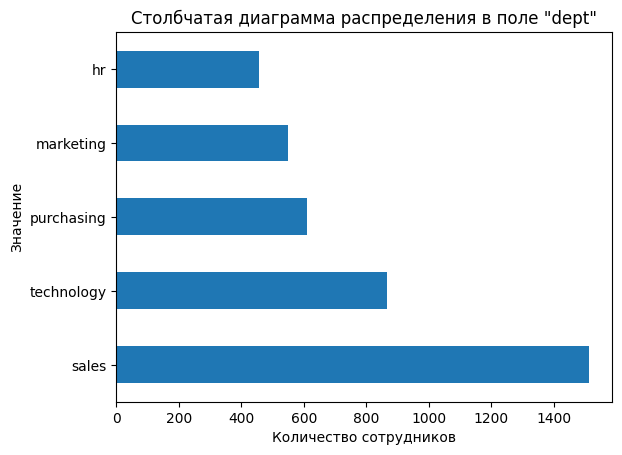

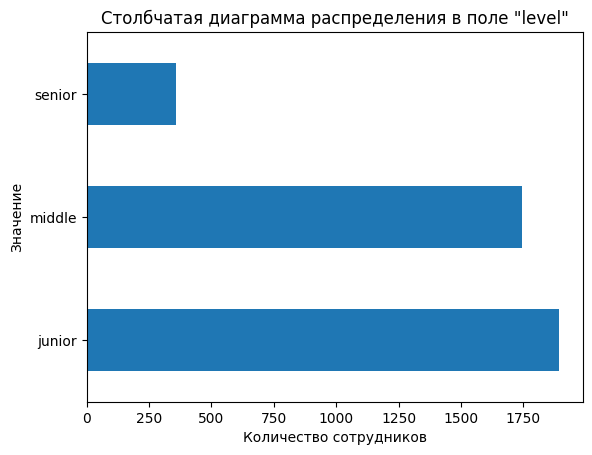

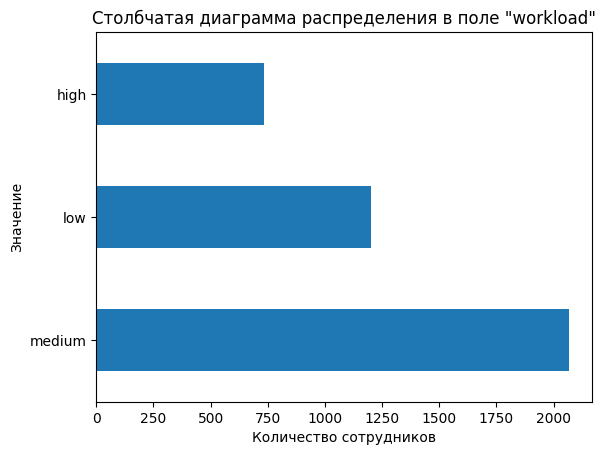

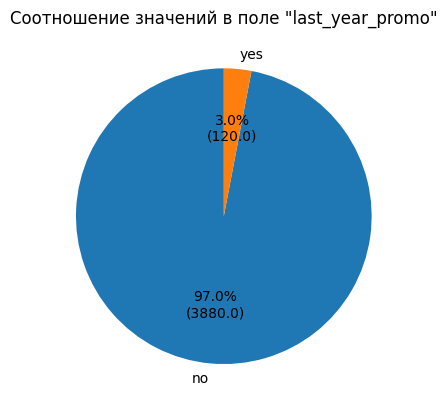

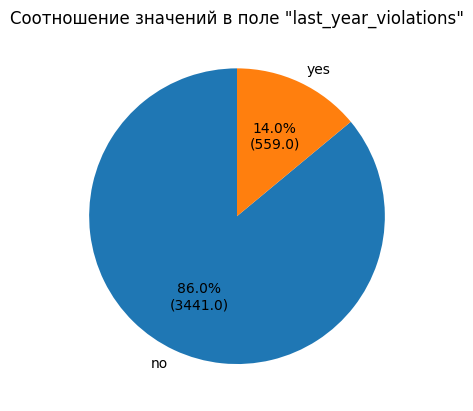

In [12]:
visualization.category_graph(train_job_satisfaction_rate, 
                             train_job_satisfaction_rate.select_dtypes(exclude='number').columns.tolist())


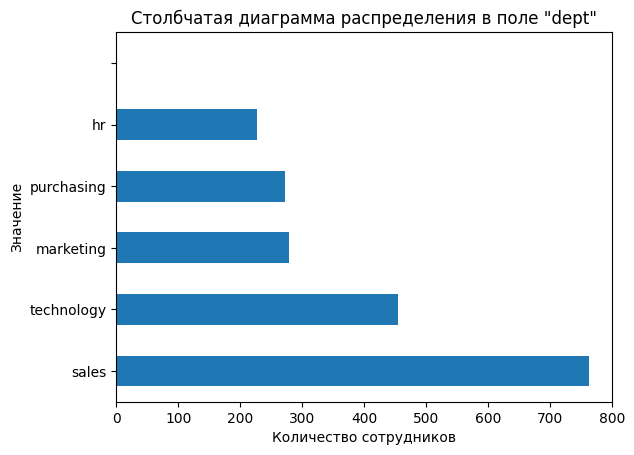

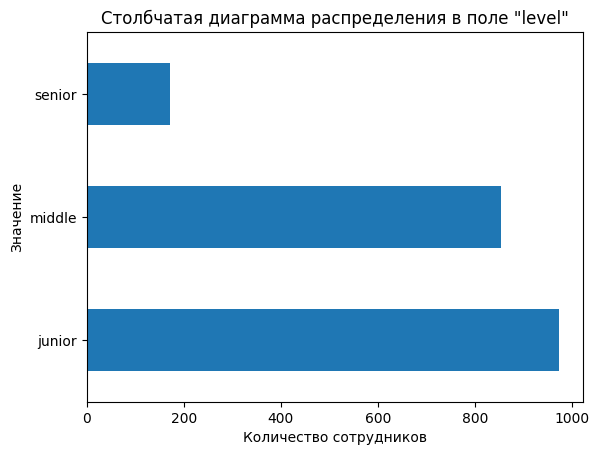

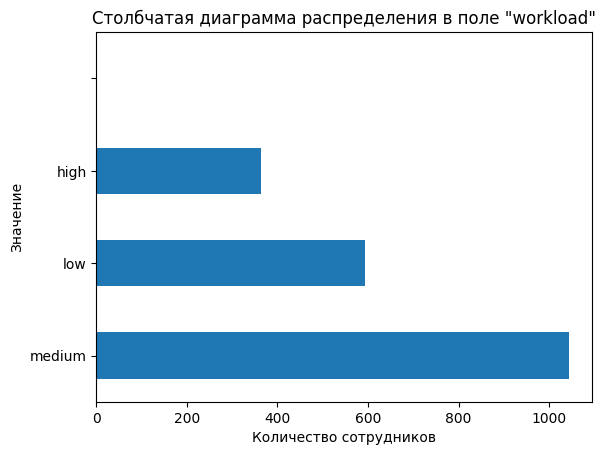

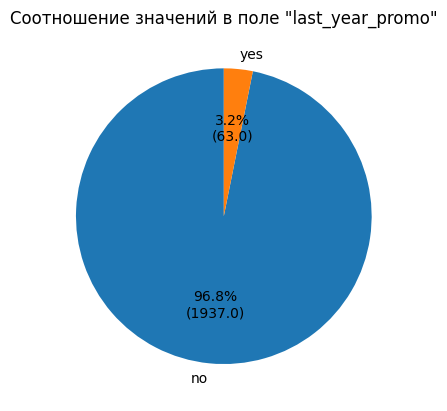

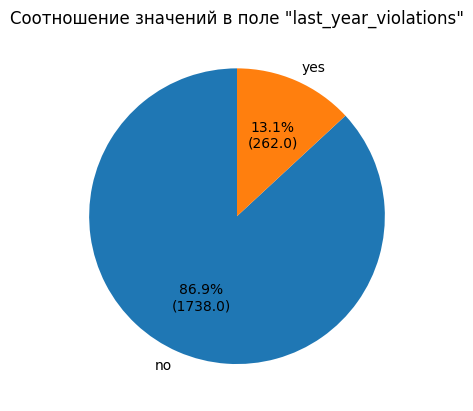

In [13]:
visualization.category_graph(test_features, 
                             test_features.select_dtypes(exclude='number').columns.tolist())


Распределения по категориальным признакам в тренировочной и тестовой выборке схожи. Самый многочисленный отдел в компании: отдел продаж. Больше всего в компании сотрудников занимающих должности начального уровня. Уровень загрузки сотрудников преимущественно средний. Всего 3% сотрудников получали повышение в последний год, при этом 13-14% сотрудников тем или иным образом нарушали трудовой договор.

Признаки `level` и `workload` являются ранговыми, в них легко можно проранжировать значения от меньшего (junior/low) до большего (senior/high). Эти признаки в дальнейшем будем кодировать с помощью OrdinalEncoder. Остальные признаки можно закодировать с помощью OneHotEncoder. 

In [14]:
test_job = test_features.join(test_target_job_satisfaction_rate)
display(test_job.head(2))


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.790
686555,hr,junior,medium,1,no,no,4,30000,0.720


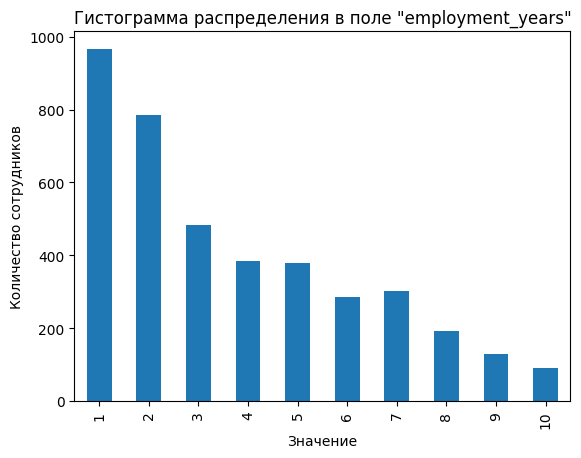

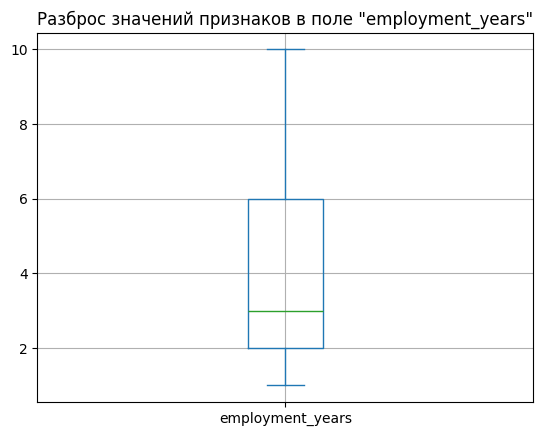

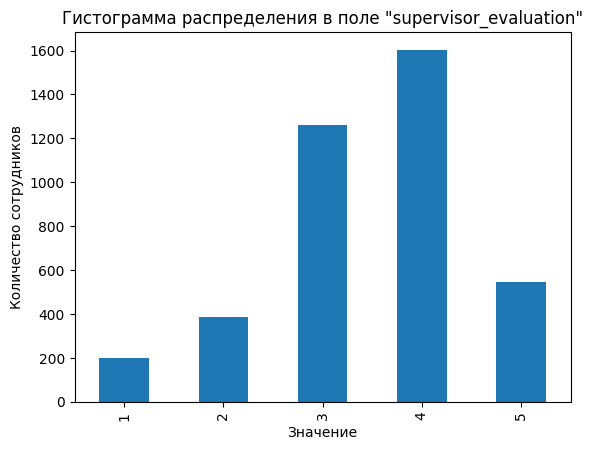

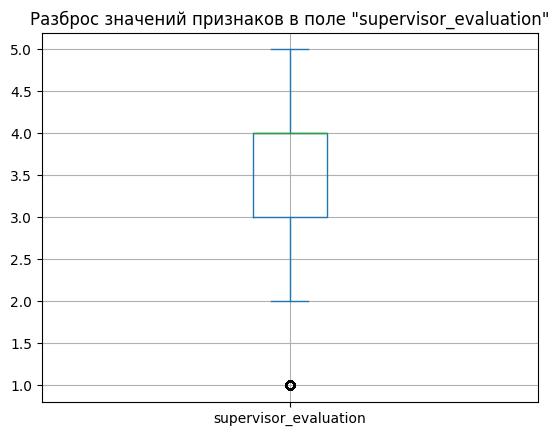

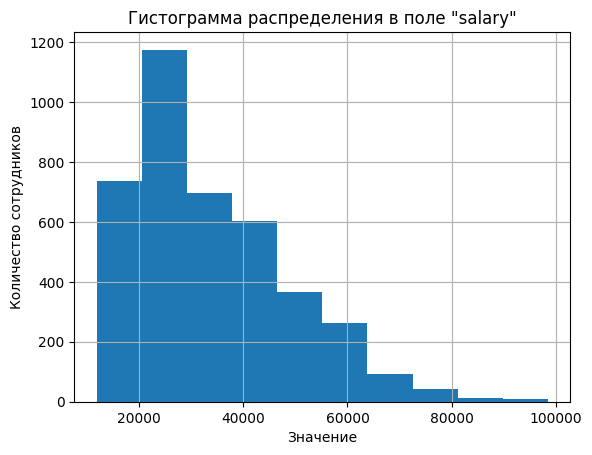

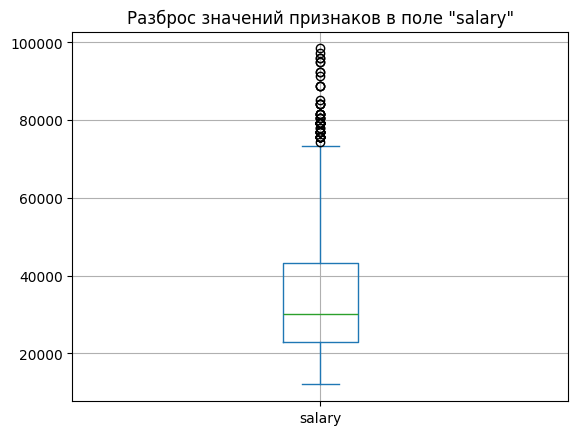

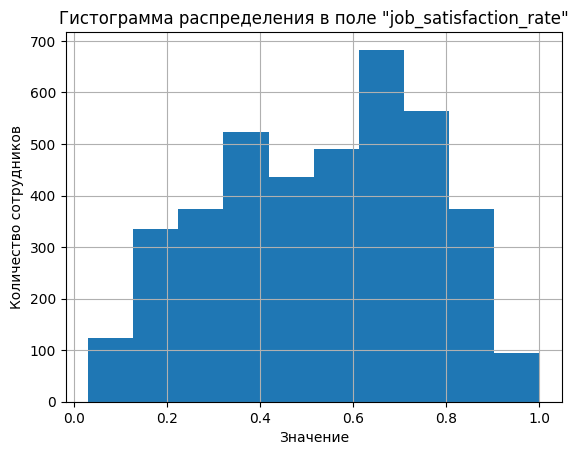

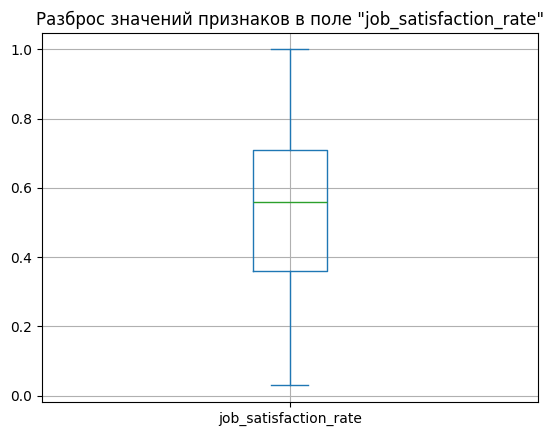

In [15]:
visualization.numeric_graph(train_job_satisfaction_rate, 
                            num_columns=train_job_satisfaction_rate.select_dtypes(include='number'),
                            exception_columns=['salary'])


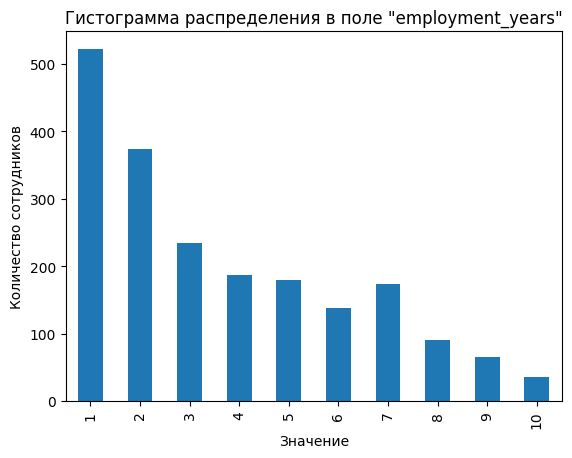

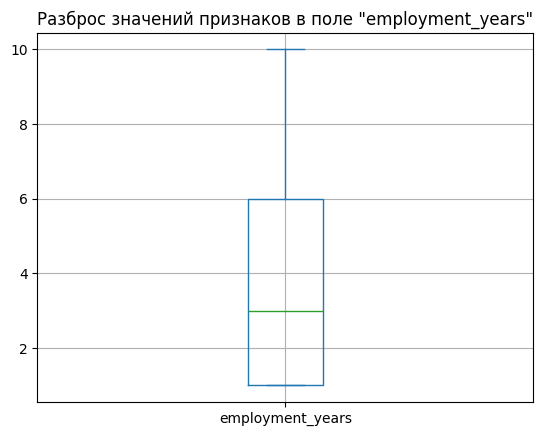

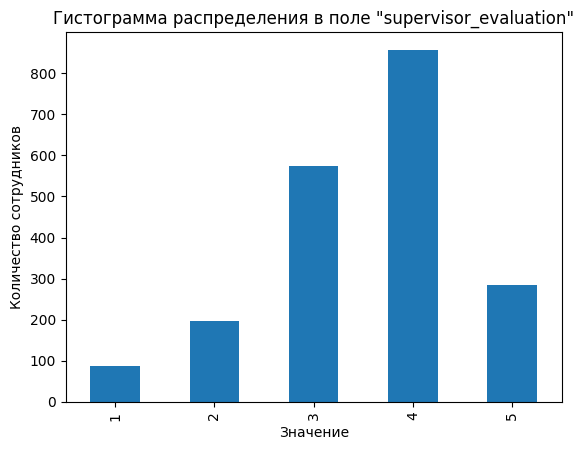

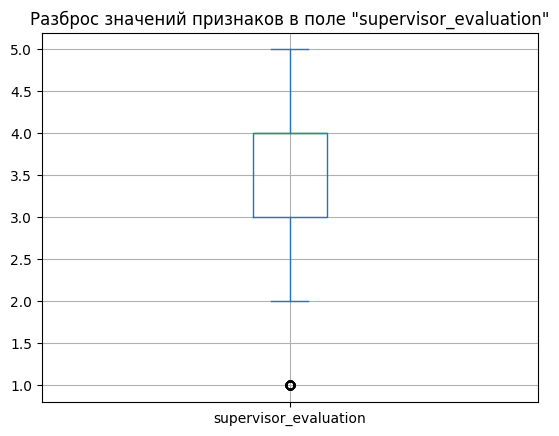

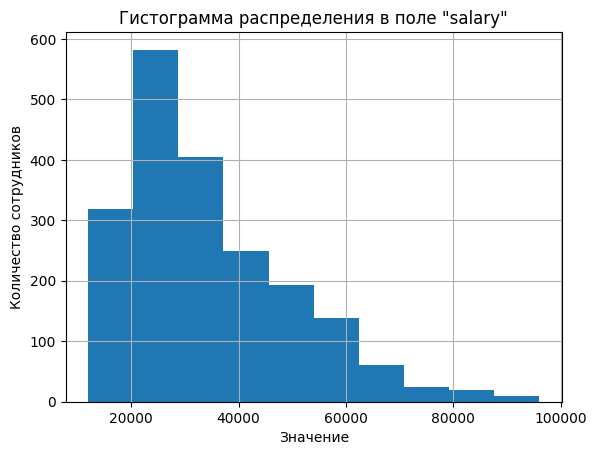

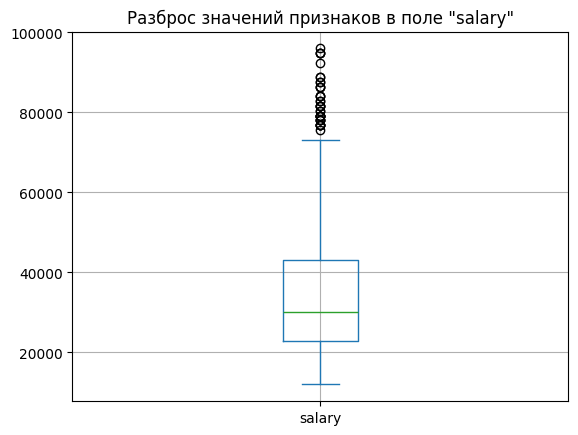

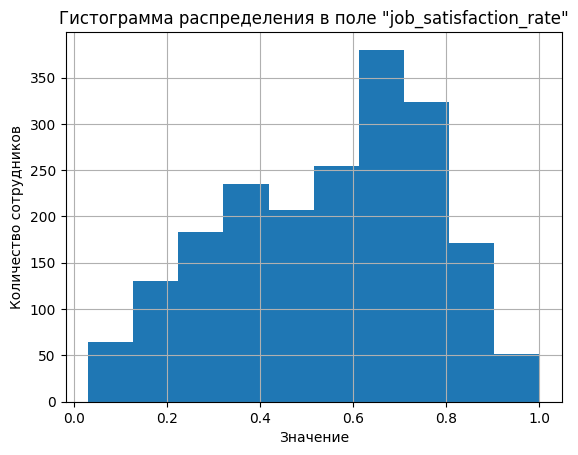

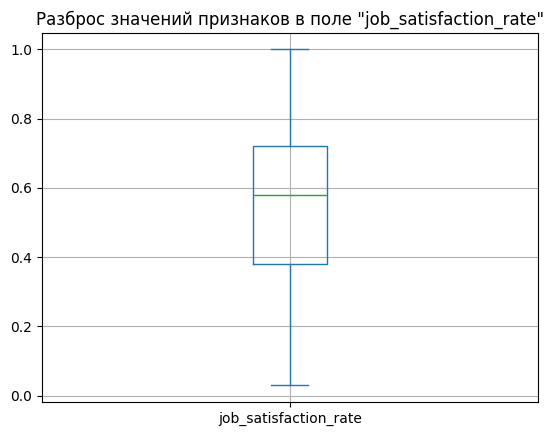

In [16]:
visualization.numeric_graph(test_job,
                            num_columns=test_job.select_dtypes(include='number'),
                            exception_columns=['salary'])


Среди количественных признаков нет ни одного с нормальным распределнием, распределения наших данных имеют длинные хвосты или ассиметрию. Краткие выводы по результатам визуализации:

**employment_years:**\
Дискретное распределение с диапазоном значений от 1 до 10. Большая часть сотрудников работает в компании недавно: 1-2 года. Явных выбросов и аномалий в данных нет.

**supervisor_evaluation:**\
Дискретное распределение с диапазоном значений от 1 до 5. Большая часть сотрудников получила среднюю оценку от руководителя: 3-4 балла. Неудовлетворительную оценку в 1 балл получило меньшинство сотрудников, на "ящике с усами" это значение отображается как выброс. Однако, такая ситуация вполне возможна и не является явной аномалией. Удалять выбросы не будем, т.к. они обусловлены особенностями данных.

**salary:**\
Распределение зарплат имеет длинный правый хвост, поэтому в данном случае медиана будет лучше характеризовать данные. Медианная зарплата составляет около 30 тыс. Заработные платы выше 75 тыс. идентифицируются как выбросы. Распределение отличается от нормального, поэтому к выявлению выбросов правилом трех сигм стоит подходить критично. В нашем случае верным будет решение оставить все данные.

**job_satisfaction_rate:**\
Большая часть сотрудников удовлетворена работой в компании (`job_satisfaction_rate` > 0.5). 

Входные количественные признаки имеют различный диапазон значений и требуют масштабирования перед подачей в модель.

Посмотрим отдельно на сотрудников, которые имеют высокий уровень удовлетворенности работой в компании (`job_satisfaction_rate` > 0.7).

In [17]:
train_job_satisfaction_rate.query('job_satisfaction_rate > 0.7').describe()


,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,"1,033.000","1,033.000","1,033.000","1,033.000"
mean,4.609,4.247,"36,607.551",0.807
std,2.612,0.460,"14,813.925",0.066
min,1.000,3.000,"12,000.000",0.710
25%,2.000,4.000,"26,400.000",0.760
50%,5.000,4.000,"33,600.000",0.800
75%,7.000,5.000,"44,400.000",0.850
max,10.000,5.000,"97,200.000",1.000


Среди сотрудников с высоким уровнем удовлетворенности работой в компании сопоставимый с общим уровень медианной зарплаты и оценки руководителей. Однако, значительно выделяется средний срок работы в компании 4-5 лет, по сравнению с 1-2 годами в общей массе. 

Посмотрим на распределение категориальных признаков среди сотрудников с высоким и низким уровнем удовлетворенности.

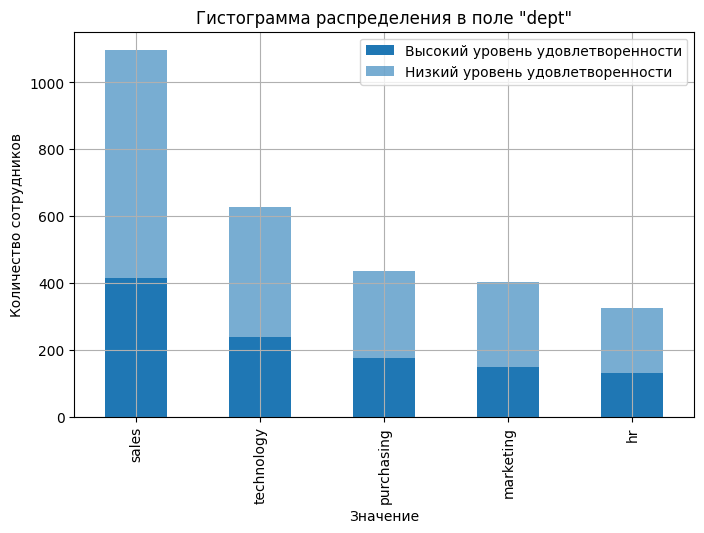

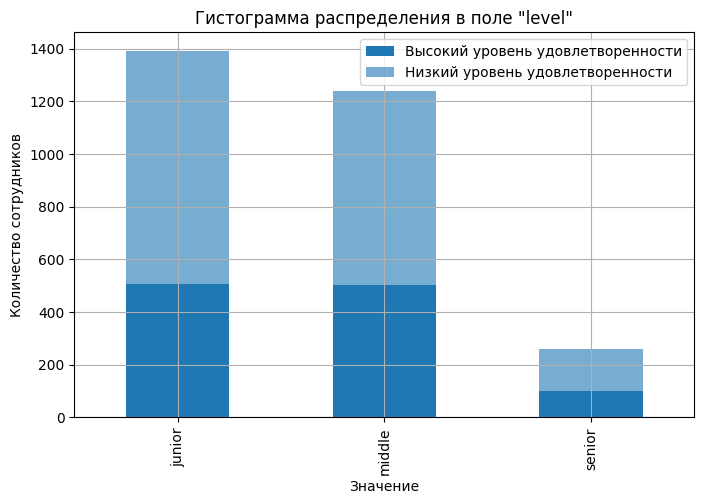

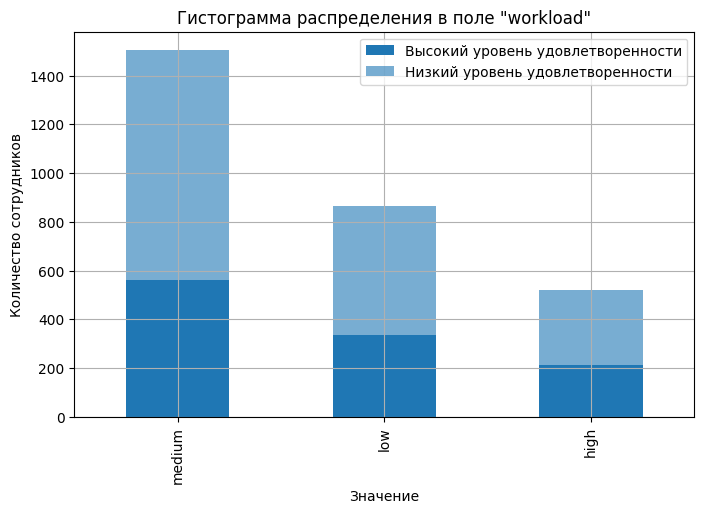

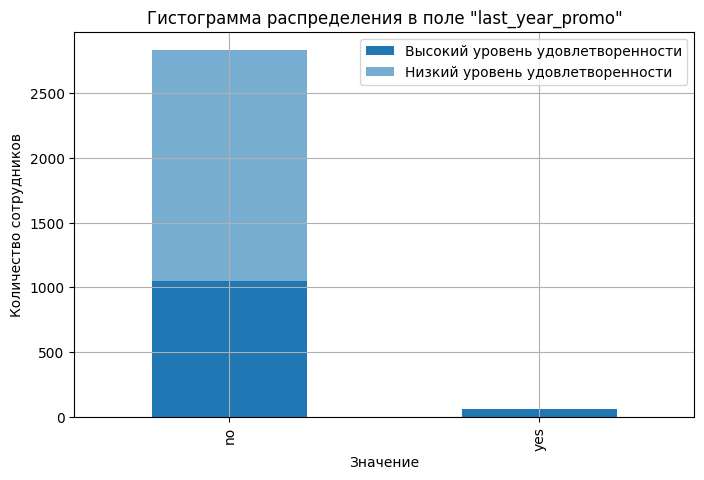

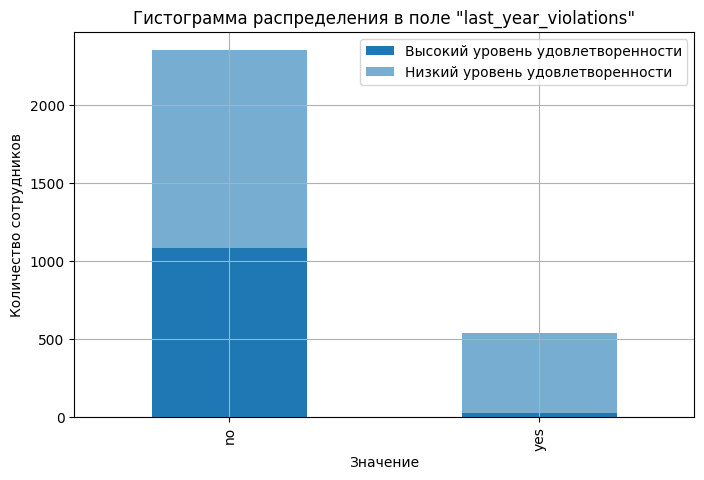

In [18]:
visualization.compare_cat_features(data_high_satisfaction = train_job_satisfaction_rate.query('job_satisfaction_rate >= 0.7'),
                                    data_low_satisfaction = train_job_satisfaction_rate.query('job_satisfaction_rate < 0.7'))


Можно отметить, что все кто получал повышение в последний год имеют высокую удовлетворенность работой в компании. Доля тех кто имеет высокий уровень удовлетворенности значительно меньше среди сотрудников имеющий начальный уровень должности. 

Перед дальнейшей работой удалим дублирующие наблюдения из тренировочной выборки.

In [19]:
print('Кол-во явных дубликатов в тренировочной выборке:', 
      train_job_satisfaction_rate.duplicated().sum())


Кол-во явных дубликатов в тренировочной выборке: 245


In [20]:
print('Размер датасета до удаления дубликатов:', train_job_satisfaction_rate.shape)
train_job_satisfaction_rate = train_job_satisfaction_rate.drop_duplicates()
print('Размер датасета после удаления дубликатов:', train_job_satisfaction_rate.shape)


Размер датасета до удаления дубликатов: (4000, 9)
Размер датасета после удаления дубликатов: (3755, 9)


<b>Вывод по разделу "Исследовательский анализ данных"</b>

В ходе анализа выявлено:
- отсутствие значимых аномалий и выбросов в данных
- данные имеют отличное от нормального распределение
- среди категориальных признаков есть как номинальные, так и ранговые. При предварительной подготовке будем использовать OrdinalEncoder и OneHotEncoder.
- количественные признаки требуют предварителнього масштабирования

1. Исходя из найденных закономерностей в данных можно составить **портрет "среднего" сотрудника компании**:
сотрудник отдела продаж на начальной должности со стажем в компании менее 2х лет и зарплатой 30 тыс. За последний год не получал повышения и не нарушал трудовой договор. Труд сотрудника хорошо оценивается руководителем. 

2. Среди сотрудников высоко оценивающих удовлетворенность работой в компании значительно выше средний стаж в компании. Все кто получают повышение имеют выскоий уровень удовлетворенности.

### Корреляционный анализ

Изучим взамосвязь между признаками в тренировочной выборке и рассчитаем коэффициенты корреляции. Т.к. у нас в данных есть как количественные так и категориальные признаки, используем коэффициент корреляции Фи. Для наглядности построим тепловую карту.

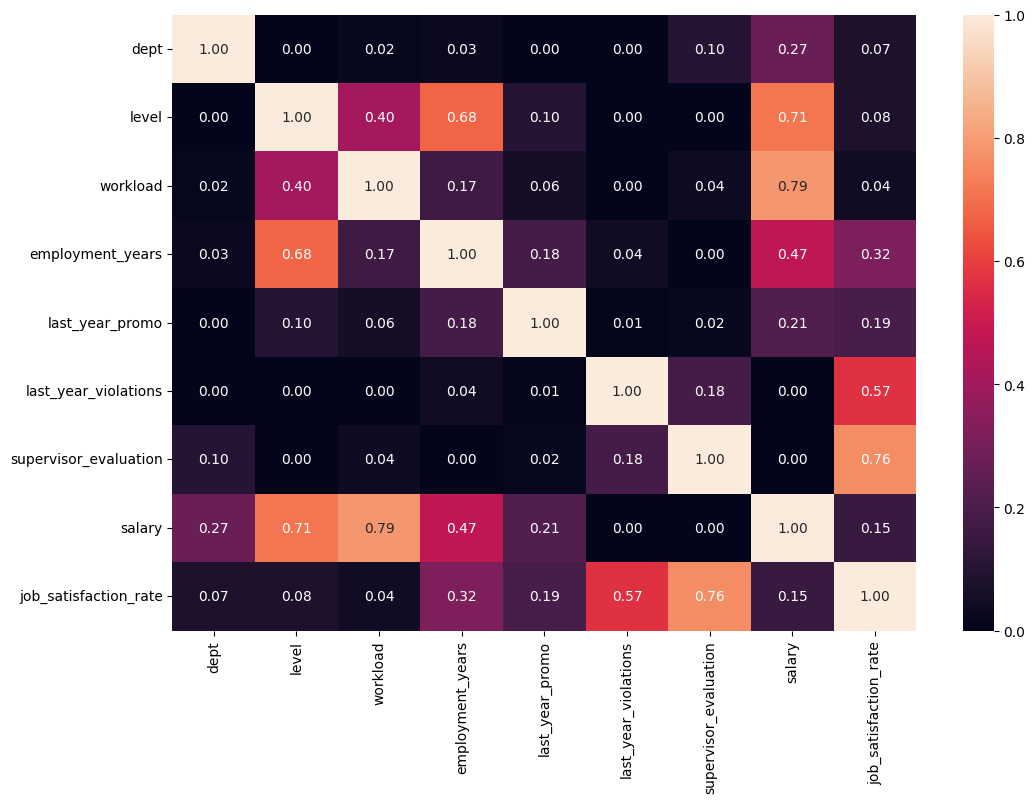

In [21]:
num_columns = train_job_satisfaction_rate.select_dtypes(include='number')
plt.figure(figsize=(12, 8))
sns.heatmap(train_job_satisfaction_rate.phik_matrix(interval_cols=num_columns), annot=True, fmt='.2f')
plt.show();


Судя по тепловой карте, самая сильная прямая связь с целевым признаком у признака с оценкой руководителя. Также заметная корреляция по шкале Чеддока (коэффициент выше 0.5) у бинарного признака, отвечающего за индикацию случаев нарушения трудового договора. Утечки данных не обнаружено.

Как правило, о мультиколлинеарности говорят при значении коэффициента от 0.9 по модулю. В наших данных таких значений нет.

Построим матрицу диаграмм рассеяния,чтобы оценить связь количественных признаков с целевым.

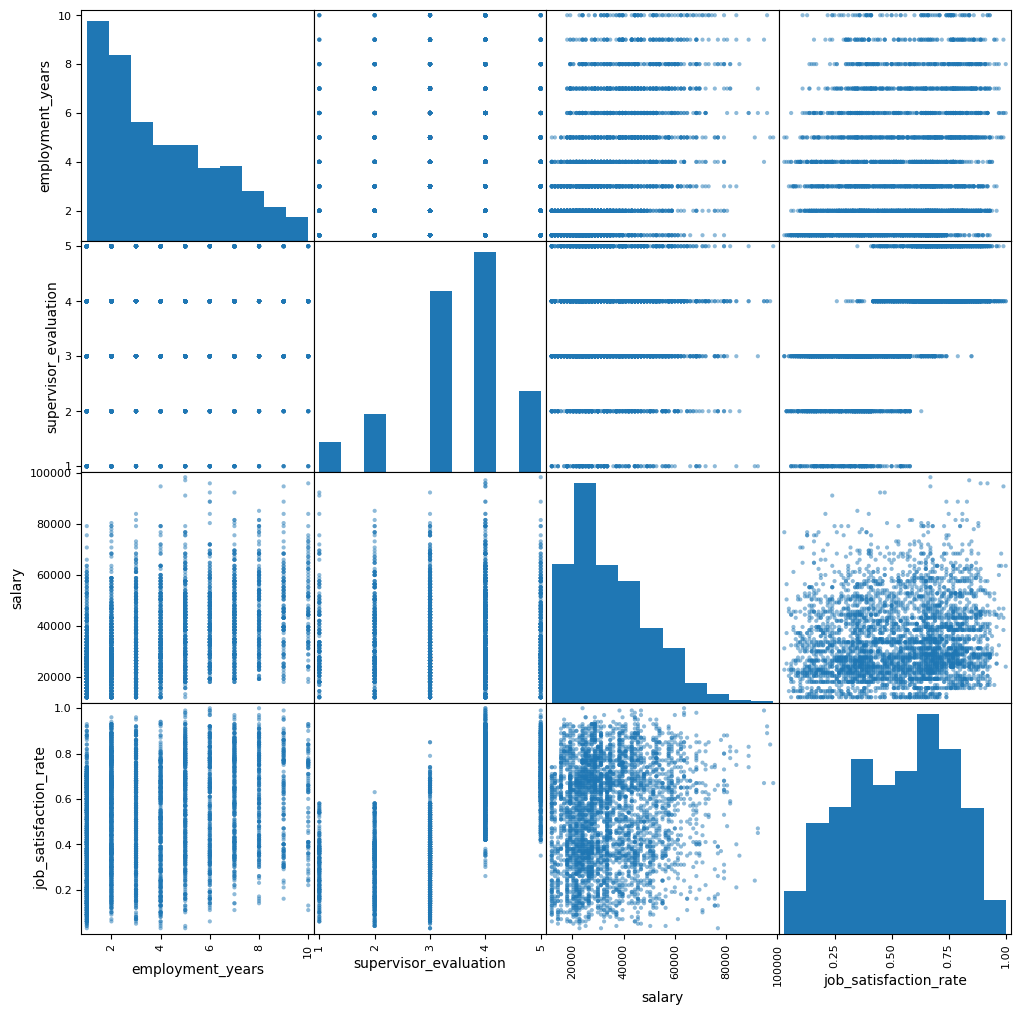

In [22]:
pd.plotting.scatter_matrix(train_job_satisfaction_rate, figsize=(12, 12));


Как видно из диаграмм рассеяния связь между целевым и количественными признаками нелинейная. В связи с этим можно сделать заключение, что линейные модели с высокой вероятностью не покажут высокого качества на этих данных.

<b>Вывод по разделу "Корреляционный анализ"</b>

- Мультиколлинеарность признаков и утечка данных не обнаружены. 
- Связь между целевым и количественными признаками нелинейная.

### Подготовка данных и разработка модели

Т.к. у нас уже есть отдельные тренировочная и тестовая выборки использование train_test_split не требуется. Удалим целевой признак из тренировочной выборки.

In [23]:
X_train = train_job_satisfaction_rate.drop(['job_satisfaction_rate'], axis=1)
y_train = train_job_satisfaction_rate['job_satisfaction_rate']


Подготовим списки с признаками, разделенные по предполагаемому методу обработки. Номинальные признаки `dept`, `last_year_violations` и `last_year_promo`, которые невозможно ранжировать закодируем с помощью OneHotEncoder. Признаки `level` и `workload` можно проранжировать, поэтому используем для него OrdinalEncoder.

In [24]:
ohe_columns = ['dept', 'last_year_violations', 'last_year_promo']
ord_columns = ['level', 'workload']
num_columns = X_train.select_dtypes(include='number').columns.tolist()


Подготовим пайплайн для обработки данных энкодерами с учетом обработки пропущенных значений. Для энкодеров установим параметр handle_unknown, который позволяет обрабатывать неизвестные категории и при необходимости и присваивать им нулевое значение. 

In [25]:
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        )
    ]
) 


In [26]:
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',  
            OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'senior'],
                    ['low', 'medium', 'high']
                ],
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
) 


Создаем общий пайплайн для подготовки данных: применяем каждый ранее созданный пайплайн к соответствующим колонкам. К количественным признакам применяем масштабирование.

In [27]:
data_preprocessor = ColumnTransformer(
    [ 
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
) 


Подготовим пайплан для обучения модели. Итоговый пайплайн включает 2 шага: 

1. Подготовка данных — шаг preprocessor.
2. Инициализация модели LinearRegression — шаг models.

In [28]:
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', LinearRegression())
    ]
) 


Для масштабирования будем использовать два скейлера: `StandardScaler()` и `MinMaxScaler()` + без масштабирования. Зададим варианты масшабирования как гиперпараметр. В дальнейшем для линейной регрессии не будем включать метод без масштабирования, чтобы избежать ситуации когда модель не сходится из-за разброса значений признаков.

In [29]:
param_grid = {
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
} 


Чтобы найти лучшее решение обучим 2 разных модели DecisionTreeRegressor() и LinearRegression(). Для "деревянной модели" подберем гиперпараметры. Для удобства перебор моделей и параметров осуществим внутри пайплайна с помощью метода GridSearchCV (переберем все варианты из заданных).

In [30]:
param_grid = [
    # словарь для модели DecisionTreeRegressor()
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(5, 20),
        'models__max_features': range(5, 20),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    # словарь для модели LogisticRegression()
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]  
    }
]


В соответствии с ТЗ в качестве метрики будем использовать SMAPE - симметричное среднее абсолютное процентное отклонение. SMAPE - это ошибка, следовательно ее необходимо минимизировать. Для корректной работы в make_scorer необходимо указать `greater_is_better`= False. 

In [31]:
smape_scorer = make_scorer(smape, greater_is_better=False)


In [32]:
grid_search = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    scoring=smape_scorer, 
    n_jobs=-1
)


In [33]:
grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'models': [DecisionTreeR...ndom_state=42)], 'models__max_depth': range(5, 20), 'models__max_features': range(5, 20), 'preprocessor__num': [StandardScaler(), MinMaxScaler(), ...]}, {'models': [LinearRegression()], 'preprocessor__num': [StandardScaler(), MinMaxScaler()]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(s...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default valu

In [34]:
print('Метрика SMAPE для лучшей модели:\n', grid_search.best_score_)
print('\nЛучшая модель и её параметры:\n\n', grid_search.best_estimator_)
print('\nЛучшие параметры\n\n', grid_search.best_params_)


Метрика SMAPE для лучшей модели:
 -15.653843203422696

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept',
                                                   'last_year_violations',
                                                   

In [35]:
result = pd.DataFrame(grid_search.cv_results_)
result[['rank_test_score', 'param_models', 'mean_test_score','params']].sort_values('rank_test_score').head()


,rank_test_score,param_models,mean_test_score,params
419,1,DecisionTreeRegressor(random_state=42),-15.654,"{'models': DecisionTreeRegressor(random_state=42), 'models__max_depth': 14, 'models__max_features': 9, 'preprocessor__num': 'passthrough'}"
417,2,DecisionTreeRegressor(random_state=42),-15.684,"{'models': DecisionTreeRegressor(random_state=42), 'models__max_depth': 14, 'models__max_features': 9, 'preprocessor__num': StandardScaler()}"
418,3,DecisionTreeRegressor(random_state=42),-15.692,"{'models': DecisionTreeRegressor(random_state=42), 'models__max_depth': 14, 'models__max_features': 9, 'preprocessor__num': MinMaxScaler()}"
379,4,DecisionTreeRegressor(random_state=42),-15.744,"{'models': DecisionTreeRegressor(random_state=42), 'models__max_depth': 13, 'models__max_features': 11, 'preprocessor__num': MinMaxScaler()}"
382,4,DecisionTreeRegressor(random_state=42),-15.744,"{'models': DecisionTreeRegressor(random_state=42), 'models__max_depth': 13, 'models__max_features': 12, 'preprocessor__num': MinMaxScaler()}"


In [36]:
X_test = test_job.drop(['job_satisfaction_rate'], axis=1)
y_test = test_job['job_satisfaction_rate']


In [37]:
y_test_pred = grid_search.predict(X_test)


In [38]:
print('Метрика SMAPE на тестовой выборке:', smape(y_test, y_test_pred))


Метрика SMAPE на тестовой выборке: 14.599008222767134


<b>Вывод по разделу "Подготовка данных и разработка модели"</b>

В ходе работы над разделом подготовлен пайплайн:
- для обработки категориальных переменных с помощью OneHotencoder и OrdinalEncoder
- для масштабирования количественных признаков использованы 3 разных метода: StandardScaler, MinMaxScaler, без масштабирования
- для поиска лучшего решения были обучены 2 модели DecisionTreeRegressor() с подбором гиперпараметром и LinearRegression(). Перебор осуществлялся методом GridSearchCV. 
- Для оценки качества в соответствии с ТЗ была выбрана собственная метрика SMAPE.

Лучшая модель - `DecisionTreeRegressor` с параметрами: models__max_depth: 14 и models__max_features: 9.

Метрика SMAPE для лучшей модели при кросс-валидации:  -15.653843203422696\
Метрика SMAPE на тестовой выборке: 14.599008222767134

Качество модели на тестовой выборке соответствует критерию успеха указанному в ТЗ: SMAPE ≤ 15.

### Анализ важности признаков

Оценим важность признаков для лучшей модели. Это поможет интерпретировать результаты модели и подготовить рекомендации для заказчика. Для этого построим график важности признаков с помощью метода SHAP. Предварительно нужно повторить обработку датасета для подачи методу через тот же пайплайн.

In [39]:
best_preprocessor = grid_search.best_estimator_.named_steps['preprocessor']

X_train_transformed = pd.DataFrame(
    best_preprocessor.transform(X_train),  
    columns=best_preprocessor.get_feature_names_out()
)

X_test_transformed = pd.DataFrame(
    best_preprocessor.transform(X_test),
    columns=best_preprocessor.get_feature_names_out()
)


In [40]:
explainer = shap.TreeExplainer(grid_search.best_estimator_[-1])
shap_values = explainer(X_test_transformed)


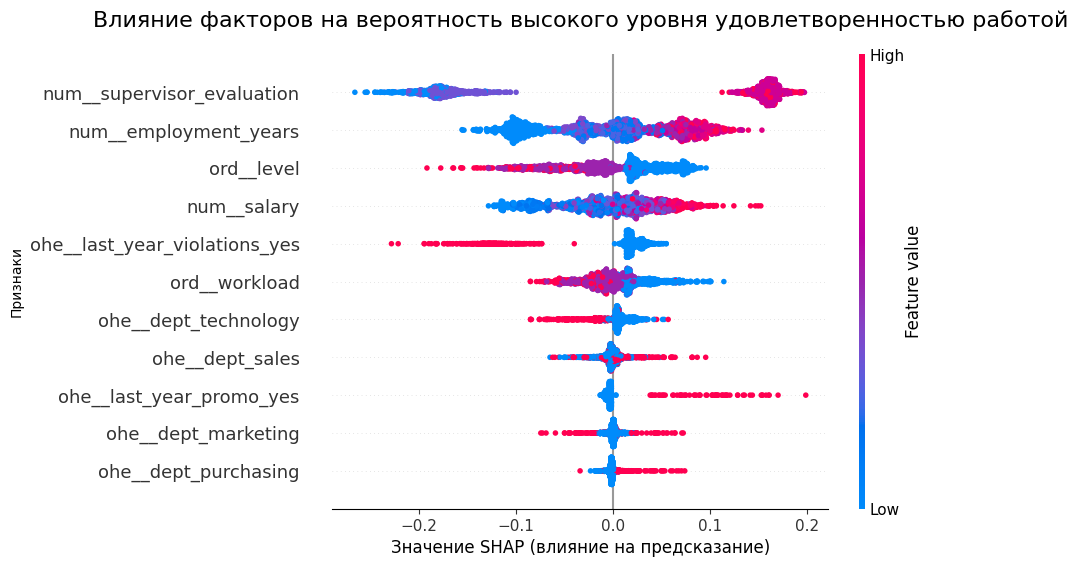

In [41]:
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title('Влияние факторов на вероятность высокого уровня удовлетворенностью работой', fontsize=16, pad=20)
plt.ylabel("Признаки")
plt.xlabel("Значение SHAP (влияние на предсказание)", fontsize=12)
plt.show()


1. Наиболее значимые признаки (по расположению сверху):
- `supervisor_evaluation`, `employment_years`, `salary`, `last_year_promo` - если у сотрудника высокая оценка руководителя, большой стаж работы, высокая зарплата и было повышение за последний год, то у него высокая вероятность принадлежности к классу с положительными результатами.
- `last_year_violations` - если у сотрудника были нарушения за последний год, это увеличивает вероятность отрицательного исхода

2. Менее значимые признаки (ближе к низу): 
- `workload` `dept` - xотя влияние этих признаков меньше, высокая загруженность, например, может указывать на стресс или переработку, что может негативно сказаться на удовлетворенности.

Мы видим достаточно широкий разброс значений Шепли, что говорит о том, что модель действительно учитывает признаки и уверенно делает предсказания.

Посмотрим на визуализацию идивидуальных SHAP-значений на примере одного из наблюдений.

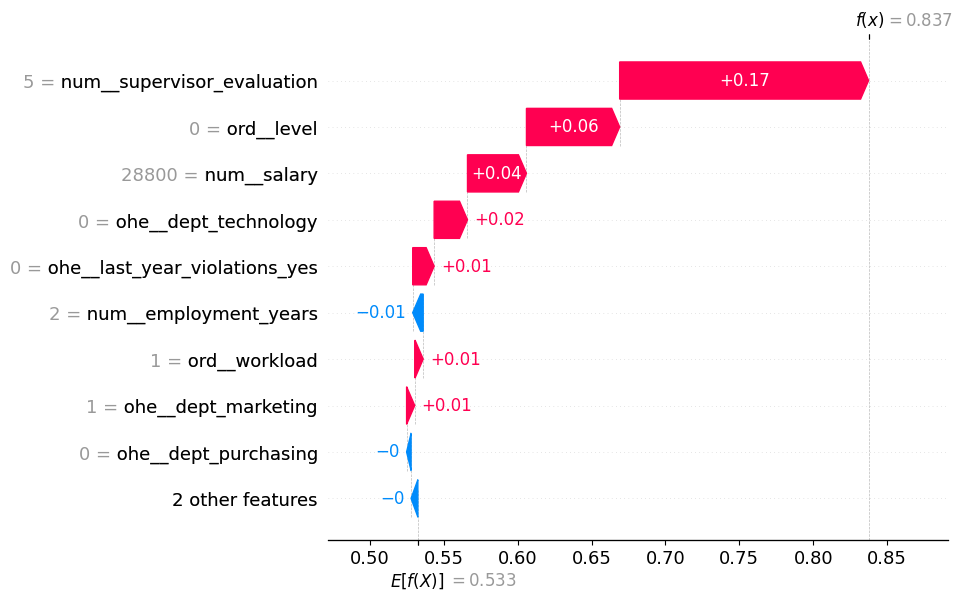

In [42]:
shap.plots.waterfall(shap_values[0]) 


Сильнее всего на классификацию этого наблюдения оказывают влияние признаки, связанные с оценкой руководителя, а также уровень должности и заработная плата. Высокое значение этих признаков позволяет предсказать высокий уровень удовлетворенности.

<b>Вывод по разделу "Анализ важности признаков"</b>

Анализ важности признаков с помощью SHAP-значений показал, что:

1. Наиболее значимые признаки: `supervisor_evaluation`, `employment_years`, `salary`, `last_year_promo`.
Чем выше их значение, тем выше удовлетворенность работой.

2. Менее значимые признаки: `workload` `dept`

С точки зрения бизнеса можно сделать вывод, что стаж работы и повышения имеют значительное влияние, что указывает на важность карьерного роста для сотрудников. Для удержания сотрудников и повышения лояльности можно разработать индивидуальные карьерные планы для каждого сотрудника, включая четкие цели, этапы развития и возможные повышения. Это может включать обучение, менторство и ротацию между отделами.

Также можно отметить, что зарплата имеет значительное влияние, что может указывать на неравномерность в оплате труда. Важно регулярно проводить анализ структуры зарплат и сравнения их с рыночными данными. Можно внедрить прозрачную систему грейдов и KPI-зависимых бонусов.

**Общий вывод по итогам разработки модели предсказания уровня удовлетворённости сотрудника:**

Разработана модель предсказания уровня удовлетворенности сотрудника работой в компании. На основании результатов модели проанализированы наиболее значимые признаки и разработаны предварительные рекомендации для удержания сотрудников и повышения лояльности, которые будут доработаны в дальнейшем по мере разработки второй модели.

**Лучшая модель**:
`DecisionTreeRegressor` с параметрами: models__max_depth: 14 и models__max_features: 9.

Метрика SMAPE для лучшей модели при кросс-валидации:  -15.653843203422696\
Метрика SMAPE на тестовой выборке: 14.599008222767134

Качество модели на тестовой выборке соответствует критерию успеха указанному в ТЗ: SMAPE ≤ 15.

**Дерево решений показало лучший результат по ряду причин**: 
- линейная регрессия может плохо работать при большом количестве категориальных переменных. В нашем половина переменных категориальная, что могло затруднить работу модели
- целевая переменная зависит от количественных признаков нелинейно, поэтому линейная регрессия просто не смогла адекватно подстроиться под особенности данных без дополнительной обработки признаков

Среди признаков оказывающих влияние на высокую вероятность снижения покупательской активности можно выделить: `supervisor_evaluation`, `employment_years`, `salary`, `last_year_promo`. Чем выше их значение, тем увереннее содель классифицирует клиета как не склонного к снижению покупательской активности.

**Рекомендации**:
1. Cтаж работы и повышения имеют значительное влияние, что указывает на важность карьерного роста для сотрудников. Можно разработать индивидуальные карьерные планы для каждого сотрудника, включая четкие цели, этапы развития и возможные повышения. Это может включать обучение, менторство и ротацию между отделами.

2. Зарплата также имеет значительное влияние, что может указывать на неравномерность в оплате труда. Важно регулярно проводить анализ структуры зарплат и сравнения их с рыночными данными. Можно внедрить прозрачную систему грейдов и KPI-зависимых бонусов.

## Предсказание увольнения сотрудника из компании

### Загрузка данных

In [43]:
train_quit = pd.read_csv('data/train_quit.csv', index_col='id')
data_info(train_quit)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 4000 строк × 9 столбцов


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no
814010,sales,junior,medium,2,no,no,4,27600,no


<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 723290 to 853842
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   4000 non-null   object
 1   level                  4000 non-null   object
 2   workload               4000 non-null   object
 3   employment_years       4000 non-null   int64 
 4   last_year_promo        4000 non-null   object
 5   last_year_violations   4000 non-null   object
 6   supervisor_evaluation  4000 non-null   int64 
 7   salary                 4000 non-null   int64 
 8   quit                   4000 non-null   object
dtypes: int64(3), object(6)
memory usage: 312.5+ KB


,count,mean,std,min,25%,50%,75%,max
employment_years,"4,000.000",3.701,2.542,1.000,2.000,3.000,6.000,10.000
supervisor_evaluation,"4,000.000",3.475,1.004,1.000,3.000,4.000,4.000,5.000
salary,"4,000.000","33,805.800","15,152.415","12,000.000","22,800.000","30,000.000","43,200.000","96,000.000"


Пропущенные значения:
Пропущенных значений нет.
Наличие дубликатов:
Найдено дубликатов: 1,413 (35.33%)


Первичный общий анализ данных в таблице `train_quit` показал, что:

 - признаки совпадают с теми, что мы использовали в предыдущей задаче
 - типы данных соответствуют информации в таблице
 - имена полей соответствуют "змеиному_регистру" и не требуют переименования
 - распределения схожи с данными из первой задачи, но не идентичны им (возможно это связано с отсутствием пропусков)
 - средние значения и медианы близки, вероятно, в данных нет значительных выбросов и аномалий
 - в выборке нет пропусков
 - есть дубликаты, которые необходимо будет обработать далее.
 
  
Тестовая выборка для второй задачи та же, что и для первой. Используем ранее подготовленные данные из датасета `test_features`.

In [44]:
test_target_quit = pd.read_csv('data/test_target_quit.csv', index_col='id')
data_info(test_target_quit)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 2000 строк × 1 столбцов


,quit
id,
999029,yes
372846,no


<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 999029 to 460332
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   quit    2000 non-null   object
dtypes: object(1)
memory usage: 31.2+ KB


,count,unique,top,freq
quit,2000,2,no,1436


Пропущенные значения:
Пропущенных значений нет.
Наличие дубликатов:
Найдено дубликатов: 1,998 (99.90%)


Количество наблюдений в таблице с целевым признаком совпадает с количеством строк в таблице с входными признаками тестовой выборки. Тип данных корректен, пропусков нет. Признак бинарный и категориальный, требует предварительной обработки с помощью LabelEncoder.

<b>Вывод по разделу "Загрузка данных"</b>

- Данные в таблицах соответствуют описанию. 
- Тестовая выборка для второй задачи та же, что и для первой. Используем ранее подготовленные данные из датасета `test_features`.

### Предобработка данных

Датасет `test_features` мы обрабатывали ранее. Проверим остальные данные.

In [45]:
check_hide_duplicate(train_quit)


Значения в поле "dept": ['sales' 'purchasing' 'marketing' 'technology' 'hr']
Значения в поле "level": ['middle' 'junior' 'sinior']
Значения в поле "workload": ['high' 'medium' 'low']
Значения в поле "last_year_promo": ['no' 'yes']
Значения в поле "last_year_violations": ['no' 'yes']
Значения в поле "quit": ['no' 'yes']
Уникальность id
Все значения в поле с идентификатором уникальны


ID в этой таблице также уникальны, следовательно, аналогичным образом удалим дубликаты перед обучением модели. Также в таблице с данными аналогичная опечатка в значении `sinior`, исправим ее и в этом случае. 

In [46]:
train_quit['level'] = train_quit['level'].str.replace('sinior', 'senior')
train_quit['level'].unique()


array(['middle', 'junior', 'senior'], dtype=object)

In [47]:
check_hide_duplicate(test_target_quit)


Значения в поле "quit": ['yes' 'no']
Уникальность id
Все значения в поле с идентификатором уникальны


<b>Вывод по разделу "Предобработка данных"</b>

В ходе предобработки удалены неточности в значениях в колонке `level`: 'sinior' заменен на 'senior.

### Исследовательский анализ данных

Проверим распределение целевого признака в тренировочной выборке. 

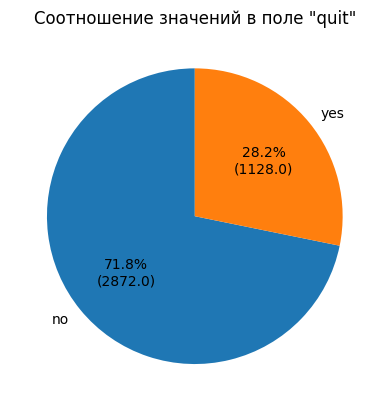

In [48]:
visualization.category_graph(train_quit, columns=['quit'])


Cоотношения значений в целевом признаке не 50/50, мы можем говорить о **дисбалансе классов**. При дисбалансе классов accuracy покажет неадекватно высокое качество модели, т.к. она не обращает внимание на плохо предсказанную принадлежность к минорному классу, а f1-мера напротив "занизит" качество модели, т.к. представляет собой среднее гармоническое precision и recall. Эти метрики при подборе подходящей стоит сразу исключить. Указанная в ТЗ метрика ROC-AUC в данном случае правильный выбор, т.к. позволит оценить качество работы модели вне зависимости от выбранного порога вероятности. К тому же, эта метрика подходит в случае, когда объектов с одним значением целевого признака больше, чем с другими.

Проанализруем признаки уволившихся сотрудников на тренировочной выборке. Распределение категорий в данных неравномерное, поэтому нормализуем количество ушедших относительно исследуемого признака. Для этого внесем правки в изначальную функцию для отрисовки графиков: сгруппируем данные по признаку и посчитаем долю таргета в каждом из значений, используя параметр `normalize=True`.

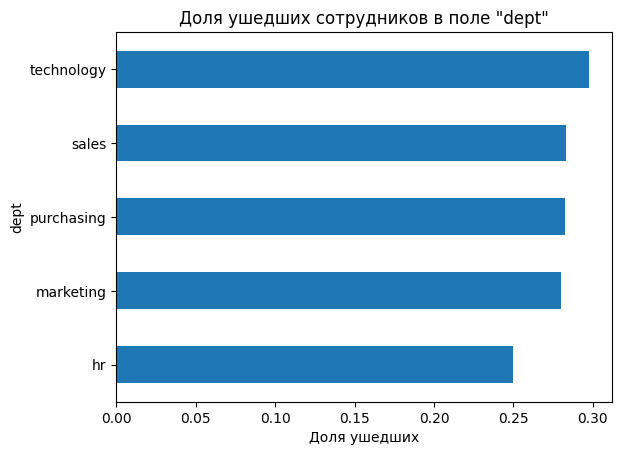

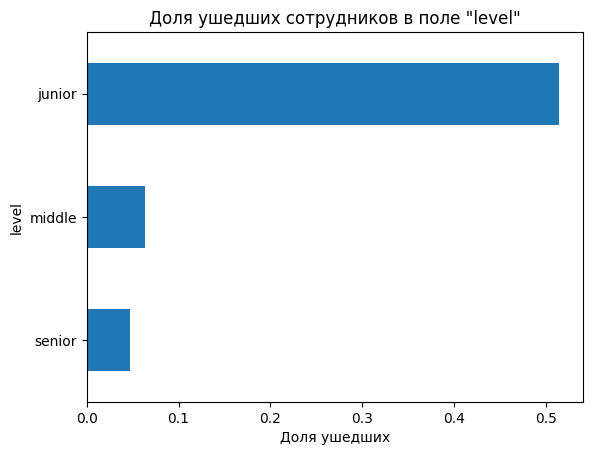

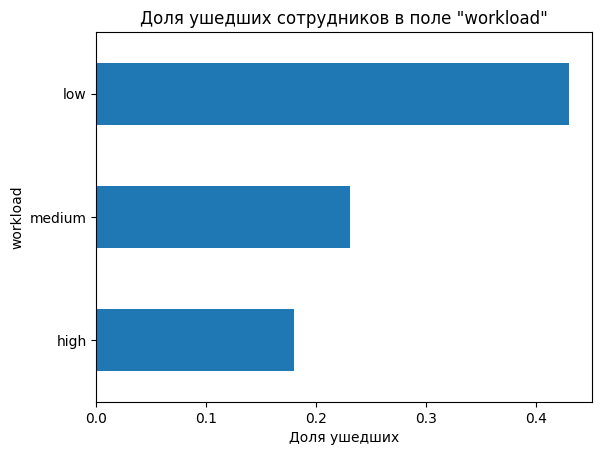

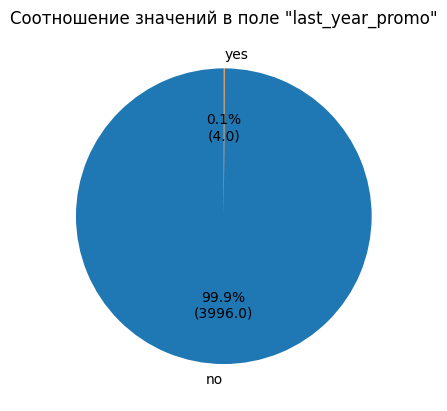

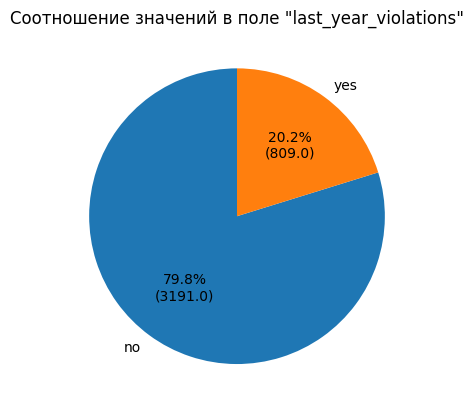

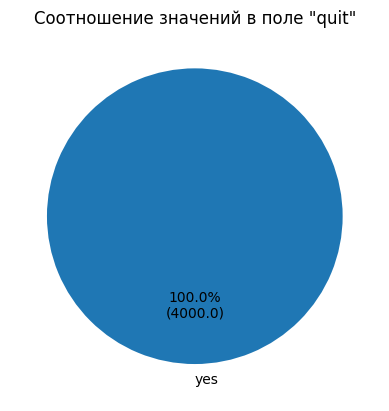

In [49]:
visualization.category_graph_normalize(train_quit, 
                                       train_quit.query('quit == "yes"'),
                                       train_quit.select_dtypes(exclude='number').columns.tolist())


По аналогии с категориальными признаками внесем изменения в отрисовку графиков количественных признаков, чтобы учитывать неравномерность распределения количества ушедших сотрудников.

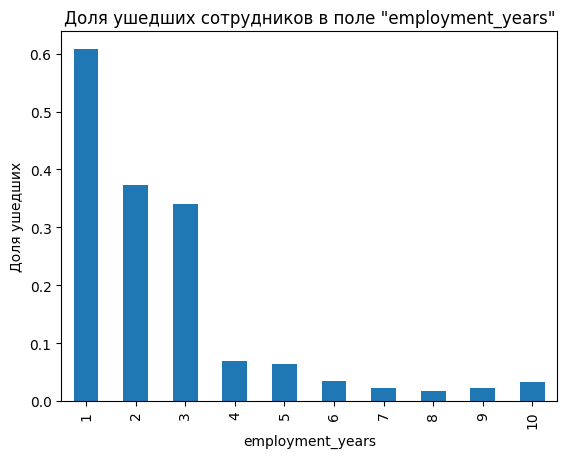

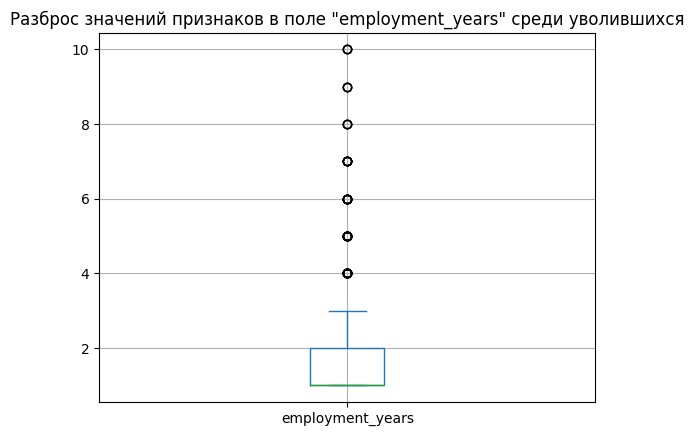

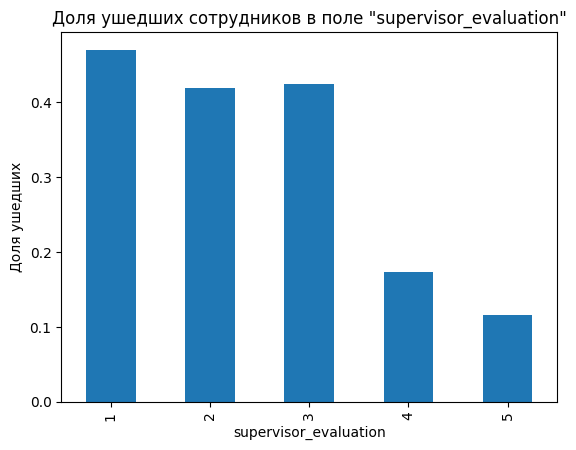

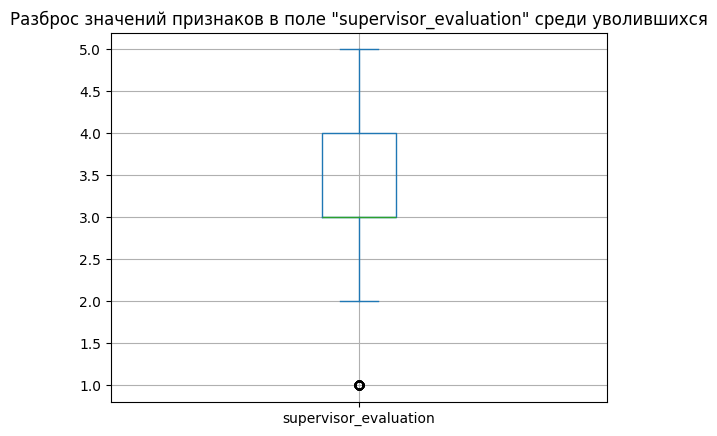

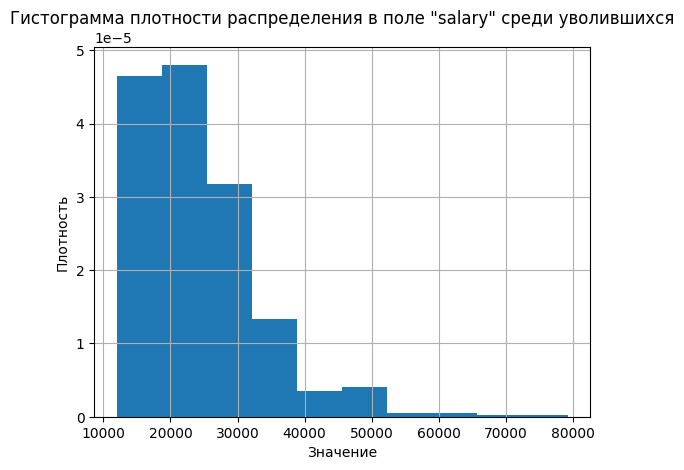

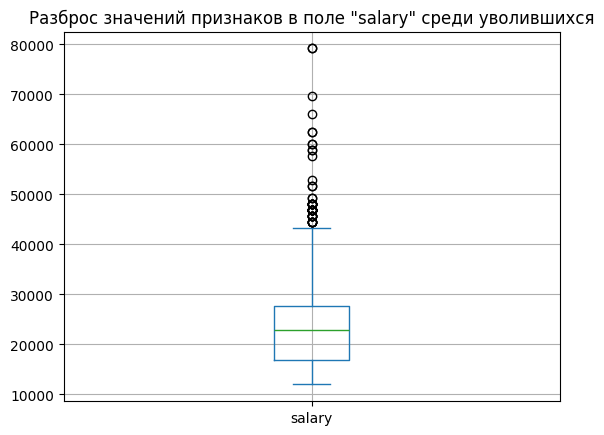

In [50]:
visualization.numeric_graph_normalize(train_quit, 
                                      train_quit.query('quit == "yes"'),
                                      train_quit.select_dtypes(include='number'),
                                      exception_columns = ['salary'])


Т.к. выборки разного размера для построения совместных гистограмм необходима нормализация по плотности. В данном случае нужно использовать параметр "density=True", так нам удастся перейти от количества к доле.

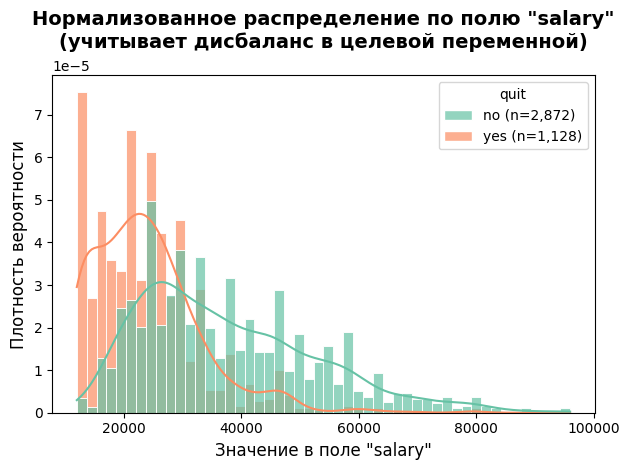

In [51]:
visualization.density_hist(train_quit,column='salary', split_col='quit')


**Портрет уволившегося сотрудника компании**: сотрудник отдела технологий на начальной должности с низкой загруженностью и стажем в компании около года и зарплатой около 15-25 тыс, что ниже чем в среднем у оставшихся в компании сотрудников. За последний год не получал повышения и чаще, чем в среднем по компании нарушал трудовой договор. Труд сотрудника низко оценивается руководителем (1-3 балла). 

Проверим утверждение аналитиков о том, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Посмотрим распределения признака job_satisfaction_rate для ушедших и оставшихся сотрудников. Используем данные из тестовой выборки.

In [52]:
test_quit = test_job.join(test_target_quit)
test_quit.head(2)


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
id,,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.790,no
686555,hr,junior,medium,1,no,no,4,30000,0.720,no


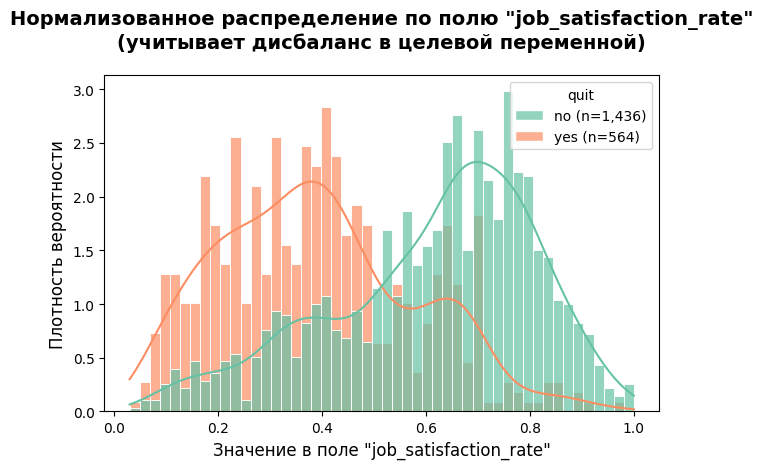

In [53]:
visualization.density_hist(test_quit,column='job_satisfaction_rate', split_col='quit')


Исходя из графиков можно сделать вывод, что уровень удовлетворенности работой в компании у уволившихся сотрудников значительно ниже, чем у тех кто остался в компании.

<b>Вывод по разделу "Исследовательский анализ данных"</b>

1. Исходя из найденных закономерностей в данных можно составить **портрет уволившегося сотрудника компании**: сотрудник отдела технологий на начальной должности с низкой загруженностью и стажем в компании около года и зарплатой около 15-25 тыс, что ниже чем в среднем у оставшихся в компании сотрудников. За последний год не получал повышения и чаще, чем в среднем по компании нарушал трудовой договор. Труд сотрудника низко оценивается руководителем (1-3 балла). 

2. Уровень удовлетворенности работой в компании у уволившихся сотрудников значительно ниже(медиана ~ 0.4), чем у тех кто остался в компании (медиана ~ 0.7).

3. В целевой переменной выявлен **дисбаланс классов**.

### Корреляционный анализ

Изучим взамосвязь между признаками в тренировочной выборке и рассчитаем коэффициенты корреляции. Используем коэффициент корреляции Фи, как и для предыдущей задачи, и для наглядности построим тепловую карту.

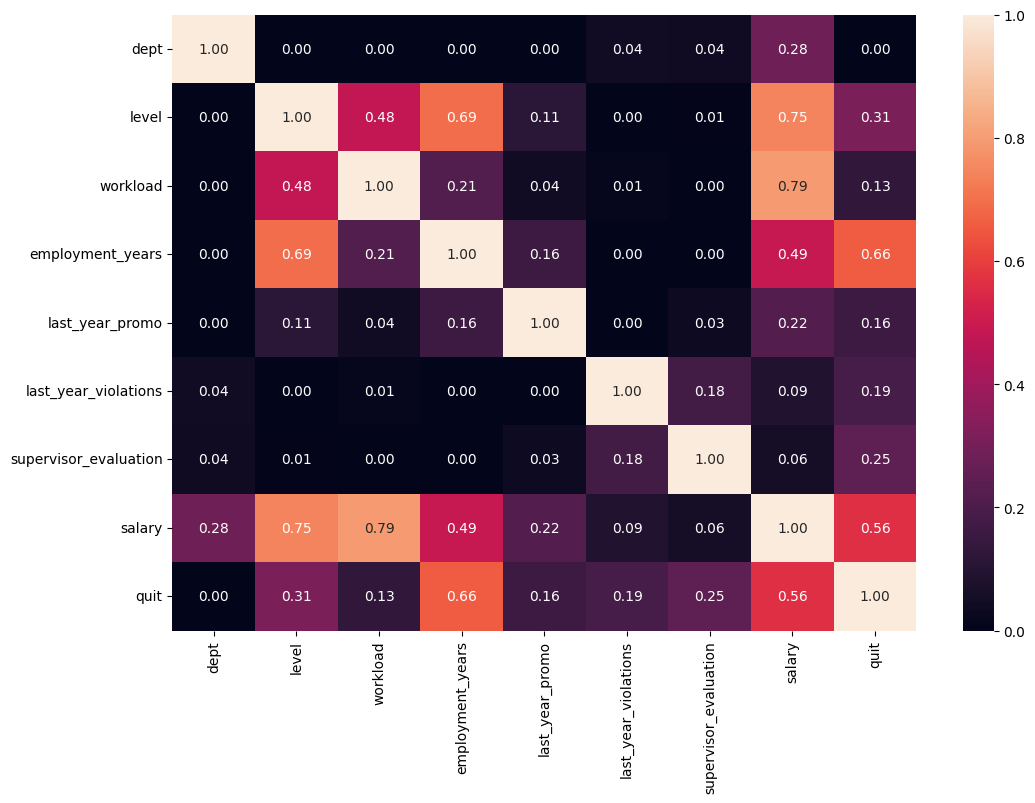

In [54]:
num_columns = train_quit.select_dtypes(include='number')
plt.figure(figsize=(12, 8))
sns.heatmap(train_quit.phik_matrix(interval_cols=num_columns), annot=True, fmt='.2f')
plt.show();


Заметная корреляция с целевым признаком по шкале Чеддока (коэффициент выше 0.5) у заработной платы и стажа работы в компании. Утечки данных не обнаружено.

Отсутсвие мультиколлинеарности между признаками мы выяснили ранее.

<b>Вывод по разделу "Корреляционный анализ"</b>

Мультиколлинеарность признаков и утечка данных не обнаружены.

###  Подготовка данных и разработка модели

Удалим дубликаты в тренировочной выборке явные дубликаты.

In [55]:
print('Кол-во явных дубликатов в тренировочной выборке:', train_quit.duplicated().sum())


Кол-во явных дубликатов в тренировочной выборке: 1413


In [56]:
print('Размер датасета до удаления дубликатов:', train_quit.shape)
train_quit = train_quit.drop_duplicates()
print('Размер датасета после удаления дубликатов:', train_quit.shape)


Размер датасета до удаления дубликатов: (4000, 9)
Размер датасета после удаления дубликатов: (2587, 9)


Т.к. у нас уже есть отдельные тренировочная и тестовая выборки использование train_test_split не требуется. Удалим целевой признак из тренировочной выборки.

In [57]:
X_train_quit = train_quit.drop(['quit'], axis=1)
y_train_quit = train_quit['quit']


Исследовательский анализ данных показал, что уровень удовлетворенности работой в компании у уволившихся сотрудников значительно ниже, чем у тех кто остался. Добавим в тренировочную  и тестовую выборки предсказанные в предыдущей задаче значения уровня удовлетворенности. 

In [58]:
X_train_quit['pred_satisfaction_rate'] = grid_search.predict(X_train_quit)
X_train_quit.head(2)


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,pred_satisfaction_rate
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,0.654
814010,sales,junior,medium,2,no,no,4,27600,0.840


In [59]:
X_test_quit = test_quit.drop(['quit', 'job_satisfaction_rate'], axis=1)
y_test_quit = test_quit['quit']


In [60]:
X_test_quit['pred_satisfaction_rate'] = grid_search.predict(X_test_quit)
X_test_quit.head(2)


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,pred_satisfaction_rate
id,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.837
686555,hr,junior,medium,1,no,no,4,30000,0.682


Закодируем предварительно целевой признак, т.к. метод ColumnTransformer его не преобразовывает. Для целевого признака используем `LabelEncoder`

In [61]:
label_encoder = LabelEncoder()
y_train_transform = label_encoder.fit_transform(y_train_quit)


Пайплайн для предобработки данных `data_preprocessor` был подготовлен для предыдущей задачи. У нас добавился количественный признак - предсказанный уровень удовлетворенности, который требует масштабирования. Обновим список колонок для предобработки.

In [62]:
ohe_columns = ['dept', 'last_year_violations', 'last_year_promo']
ord_columns = ['level', 'workload']
num_columns = X_train_quit.select_dtypes(include='number').columns.tolist()


Чтобы найти лучшее решение обучим 3 разных модели: SVC(), DecisionTreeClassifier() и LogisticRegression(). Для каждой подберем гиперпараметры. Для удобства перебор моделей осуществим внутри пайплайна. Т.к. в данных присутствует дисбаланс классов используем метод class_weights='balanced'.  

Дл масштабирования будем использовать два скейлера: `StandardScaler()` и `MinMaxScaler()` + метод без масштабирования. Зададим варианты масшабирования как гиперпараметр. Для логистической регрессии не будем включать метод без масштабирования, чтобы избежать ситуации когда модель не сходится из-за разброса значений признаков.

In [63]:
param_distributions = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE,
                                          class_weight='balanced')],
        'models__max_depth': range(2, 10),
        'models__max_features': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            class_weight='balanced',
            solver='saga', 
            penalty='elasticnet',
            max_iter=3000
        )],
        'models__C': range(5, 20),
        'models__l1_ratio': [0, 0.2, 0.5, 0.8, 1],
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]  
    },
     # словарь для модели SVC()
    {
        'models': [SVC(random_state=RANDOM_STATE,
                       class_weight='balanced',
                       probability=True)],
        'models__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'models__degree': range(1, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]


Осталось запустить автоматический подбор с помощью RandomizedSearchCV. В качестве метрики, согласно ТЗ, будем использовать roc-auc.

In [64]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_distributions=param_distributions, 
    scoring='roc_auc', 
    random_state=RANDOM_STATE,
    n_jobs=-1
)


In [65]:
randomized_search.fit(X_train_quit, y_train_transform)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'models': [DecisionTreeC...ndom_state=42)], 'models__max_depth': range(2, 10), 'models__max_features': range(2, 10), 'preprocessor__num': [StandardScaler(), MinMaxScaler(), ...]}, {'models': [LogisticRegre...solver='saga')], 'models__C': range(5, 20), 'models__l1_ratio': [0, 0.2, ...], 'preprocessor__num': [StandardScaler(), MinMaxScaler()]}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allothe

In [66]:
print('Метрика ROC_AUC для лучшей модели:\n', randomized_search.best_score_)
print('\nЛучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print('\nЛучшие параметры\n\n', randomized_search.best_params_)


Метрика ROC_AUC для лучшей модели:
 0.9046699709659812

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept',
                                                   'last_year_violations',
                                                  

In [67]:
result = pd.DataFrame(randomized_search.cv_results_)
result[['rank_test_score', 'param_models', 'mean_test_score','params']].sort_values('rank_test_score').head()


,rank_test_score,param_models,mean_test_score,params
1,1,"SVC(class_weight='balanced', probability=True, random_state=42)",0.905,"{'preprocessor__num': StandardScaler(), 'models__kernel': 'rbf', 'models__degree': 9, 'models': SVC(class_weight='balanced', probability=True, random_state=42)}"
8,2,"LogisticRegression(class_weight='balanced', max_iter=3000, penalty='elasticnet',\n random_state=42, solver='saga')",0.902,"{'preprocessor__num': StandardScaler(), 'models__l1_ratio': 0.8, 'models__C': 12, 'models': LogisticRegression(class_weight='balanced', max_iter=3000, penalty='elasticnet', random_state=42, solver='saga')}"
6,3,"LogisticRegression(class_weight='balanced', max_iter=3000, penalty='elasticnet',\n random_state=42, solver='saga')",0.902,"{'preprocessor__num': MinMaxScaler(), 'models__l1_ratio': 0.2, 'models__C': 18, 'models': LogisticRegression(class_weight='balanced', max_iter=3000, penalty='elasticnet', random_state=42, solver='saga')}"
9,4,"LogisticRegression(class_weight='balanced', max_iter=3000, penalty='elasticnet',\n random_state=42, solver='saga')",0.902,"{'preprocessor__num': MinMaxScaler(), 'models__l1_ratio': 0.5, 'models__C': 15, 'models': LogisticRegression(class_weight='balanced', max_iter=3000, penalty='elasticnet', random_state=42, solver='saga')}"
4,5,"SVC(class_weight='balanced', probability=True, random_state=42)",0.890,"{'preprocessor__num': MinMaxScaler(), 'models__kernel': 'linear', 'models__degree': 7, 'models': SVC(class_weight='balanced', probability=True, random_state=42)}"


Проверим качество модели на тестовых данных, предварительно подготовив данные. По ТЗ метрика ROC-AUC должна быть ≥0.91.

In [68]:
y_test_transform = label_encoder.transform(y_test_quit)


In [69]:
y_test_pred = randomized_search.predict_proba(X_test_quit)[:, 1]


In [70]:
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test_transform, y_test_pred)}')


Метрика ROC-AUC на тестовой выборке: 0.9159178124814792


<b>Вывод по разделу "Подготовка данных и разработка модели"</b>

В ходе работы над разделом подготовлен пайплайн:
- для предобработки использовался подготовленный ранее пайплайн. Новый признак - уровень удовлетворенности -  масштабирован
- целевой признак закодирован с помощью LabelEncoder
- для поиска лучшего решения были обучены 3 модели SVC(), DecisionTreeClassifier() и LogisticRegression() с подбором гиперпарметров. Перебор осуществлялся методом RandomizedSearchCV. 
- для решения проблемы дисбаланса кллассов для всех моделей использован метод class_weights='balanced'. 
- Для оценки качества в соответствии с ТЗ была выбрана метрика ROC-AUC.

Лучшая модель - `SVC` с гиперпараметром degree=9.

Метрика ROC-AUC для лучшей модели при кросс-валидации:  0.9046699709659812\
Метрика ROC-AUC на тестовой выборке: 0.9159178124814792

Качество модели на тестовой выборке соответствует критерию успеха указанному в ТЗ: ROC-AUC ≥0.91.

### Анализ важности признаков

Оценим важность признаков для лучшей модели. Это поможет интерпретировать результаты модели и подготовить рекомендации для заказчика. Для этого построим график важности признаков с помощью метода SHAP. Предварительно нужно повторить обработку датасета для подачи методу через тот же пайплайн.

In [71]:
best_preprocessor_quit = randomized_search.best_estimator_.named_steps['preprocessor']

X_train_quit_transformed = pd.DataFrame(
    best_preprocessor_quit.fit_transform(X_train_quit),
    columns=best_preprocessor_quit.get_feature_names_out()
)
X_test_quit_transformed = pd.DataFrame(
    best_preprocessor_quit.transform(X_test_quit),
    columns=best_preprocessor_quit.get_feature_names_out()    
) 


Для модели SVC для получения SHAP-значений необходимо использовать метод shap.KernelExplainer, который работает очень медленно на больших данных, так как использует метод Монте-Карло для приближенной оценки SHAP-значений. Попробуем оценить важность признаков на небольшой выборке из тестовой.

In [72]:
best_model = randomized_search.best_estimator_.named_steps['models']
X_test_quit_sample = shap.sample(X_test_quit_transformed, 100, random_state=RANDOM_STATE)


In [73]:
explainer = shap.KernelExplainer(best_model.predict_proba, X_test_quit_sample)
shap_values = explainer(X_test_quit_sample)


  0%|          | 0/100 [00:00<?, ?it/s]

Создадим объект Explanation, который содержит SHAP-значения для класса 1, т.е. уволившихся и оценим вклад всех признаков в классификацию на нашем семпле из тестовых данных.

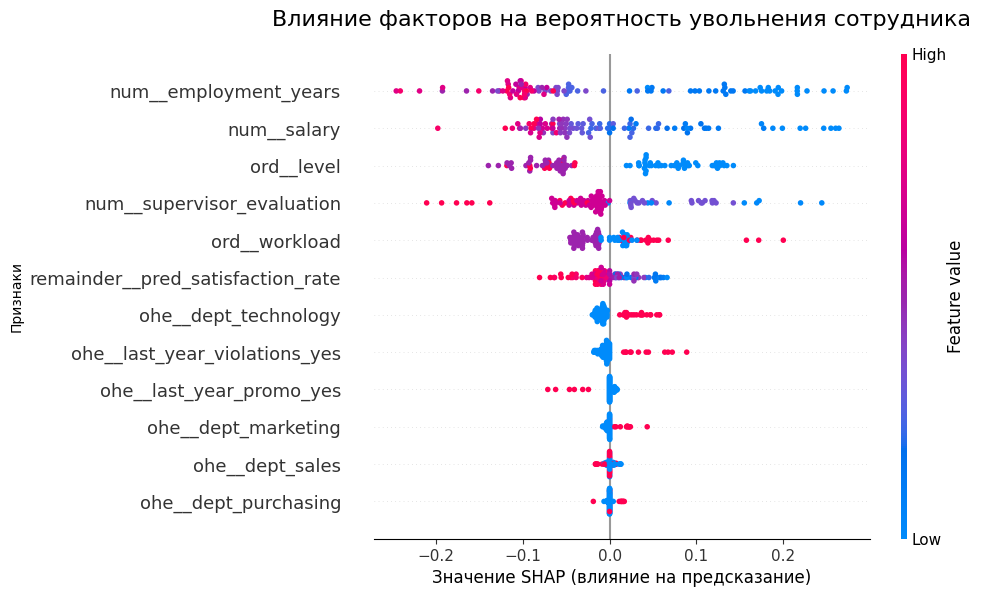

In [74]:
shap_values_quit = shap.Explanation(values=shap_values.values[:, :, 1], 
                                    base_values=shap_values.base_values[:, 1],
                                    data=shap_values.data,  
                                    feature_names=shap_values.feature_names)

shap.plots.beeswarm(shap_values_quit, max_display=15, show=False)
plt.title('Влияние факторов на вероятность увольнения сотрудника', fontsize=16, pad=20)
plt.ylabel("Признаки")
plt.xlabel("Значение SHAP (влияние на предсказание)", fontsize=12)
plt.show()



1. Среди важных признаков на семпле из 100 наблюдений из тестовых данных можно выделить:
- уровень должности: чем выше должность, тем  ниже вероятность увольнения
- уровень нагрузки имеет обратное действие: чем ниже нагрузка, тем  ниже вероятность увольнения
- уровень удовлетворенности работой в компании: чем ниже уровень удовлетворенности, тем выше вероятность, что сотрудник уволится. 
- уровень з/пл: чем ниже зп, тем выше вероятность увольнения

3. Наименее значимые признаки: принадлежность к определенному отделу.

<b>Вывод по разделу "Анализ важности признаков"</b>

Анализ важности признаков с помощью SHAP-значений показал, что:

1. Среди значимых признаков можно выделить `level`, `workload`,  `pred_satisfaction_level` и  `supervisor_evaluation`. Чем выше оценка руководителя, должность и уровень удовлетворенности, тем ниже вероятность увольнения сотрудника. Чем выше нагрузка, тем выше вероятность уольнения.

3. Наименее значимый признак: принадлежность к определенному отделу, который практически не оказывает влияние на классификацию.

В дополнение к ранее предыдущим рекомендациям по итогам первой модели можно предложить:

- Повышение удовлетворенности работой: Удовлетворенность работой — важный фактор. Рекомендуется проводить регулярные опросы сотрудников, улучшать условия труда и внедрять программы обратной связи.

- Оптимизация рабочей нагрузки: Проведите анализ текущей нагрузки на сотрудников и определите, есть ли сотрудники, которые перегружены работой. Если да, рассмотрите возможность перераспределения задач или найма дополнительного персонала для снижения нагрузки.

**Общий вывод по итогам разработки модели прогнозирования вероятности увольнения сотрудника:**

Разработана модель прогнозирования вероятности увольнения сотрудника (отток персонала). На основании результатов модели проанализированы наиболее значимые признаки и разработаны дополнительные рекомендации для удержания сотрудников и повышения лояльности.

**Лучшая модель**:
Лучшая модель - `SVC` с гиперпараметром degree=9.

Метрика ROC-AUC для лучшей модели при кросс-валидации:  0.9046699709659812\
Метрика ROC-AUC на тестовой выборке: 0.9159178124814792

Качество модели на тестовой выборке соответствует критерию успеха указанному в ТЗ: ROC-AUC ≥0.91.

**Метод опорных векторов показал лучший результат**: 
Вероятно, это связано с тем, что SVC часто показывает лучшие результаты на небольших и средних выборках с четкими разделяющими границами. После удаления повторяющихся наблюдений из тренировочной выборки, она стала достаточно небольшой. Высокий degree=9 позволил модели улавливать сложные нелинейные зависимости между признаками, что особенно важно, т.к. в наших данных ьольшое количество категориальных данных. 

Среди значимых признаков можно выделить `level`, `workload`,  `pred_satisfaction_level` и  `supervisor_evaluation`. Чем выше оценка руководителя, должность и уровень удовлетворенности, тем ниже вероятность увольнения сотрудника. Чем выше нагрузка, тем выше вероятность уольнения.

**Рекомендации**:
1. Рекомендуется проводить регулярные опросы сотрудников, улучшать условия труда и внедрять программы обратной связи, чтобы повысить уровень удовлетворенности работой.

2. Рекомендуется провести анализ текущей нагрузки на сотрудников и при необходимости рассмотреть возможность перераспределения задач или найма дополнительного персонала для снижения нагрузки.

## Общий вывод

В ходе проекта перед нами стояла задача создания прогнозных моделей машинного обучения:
- Модель предсказания уровня удовлетворенности сотрудника работой в компании
- Модель прогнозирования вероятности увольнения сотрудника (отток персонала)
- Разработка рекомендаций для бизнеса по работе с сотрудниками для снижения оттока сотрудников и оптимизации управления кадрами.

Были разработаны модели:
1. **Лучшая модель прогнозирования уровня удовлетворенности сотрдуника**:
`DecisionTreeRegressor` с параметрами: models__max_depth: 14 и models__max_features: 9.

Метрика SMAPE для лучшей модели при кросс-валидации:  -15.653843203422696\
Метрика SMAPE на тестовой выборке: 14.599008222767134

Качество модели на тестовой выборке соответствует критерию успеха указанному в ТЗ: SMAPE ≤ 15.

2. **Лучшая модель прогнозирования оттока персонала**:
`SVC` с параметрами: class_weight='balanced', degree=9, probability=True, random_state=42

Метрика ROC-AUC для лучшей модели при кросс-валидации:  0.9046699709659812\
Метрика ROC-AUC на тестовой выборке: 0.9159178124814792

Качество модели на тестовой выборке соответствует критерию успеха указанному в ТЗ: ROC-AUC ≥0.91.

В ходе проекта были выполнены следующие этапы:
1. В ходе предобработки:
- удалены неточности в значениях в колонке `level`: 'sinior' заменен на 'senior.
- обработаны нестандартные пустые значения в тестовой выборке с входными признаками: ' ' заменены на np.nan
- предобработка пропусков для замены на самые часто встречающиеся оформлена в пайплайн 

2. Исходя из найденных закономерностей в данных при анализе были составлены:
- **портрет "среднего" сотрудника компании**: сотрудник отдела продаж на начальной должности со стажем в компании менее 2х лет и зарплатой 30 тыс. За последний год не получал повышения и не нарушал трудовой договор. Труд сотрудника хорошо оценивается руководителем. 
- **портрет уволившегося сотрудника компании**: сотрудник отдела технологий на начальной должности с низкой загруженностью и стажем в компании около года и зарплатой около 15-25 тыс, что ниже чем в среднем у оставшихся в компании сотрудников. За последний год не получал повышения и чаще, чем в среднем по компании нарушал трудовой договор. Труд сотрудника низко оценивается руководителем (1-3 балла). Уровень удовлетворенности работой в компании у уволившихся сотрудников значительно ниже(медиана ~ 0.4), чем у тех кто остался в компании (медиана ~ 0.7).

3. В ходе исследовательского анализа:
- было установлено, что данные имеют отличное от нормального распределение. Целевой признак - удовлетворенность сотрудника -  имеет нелинейную связь с количественными признаками.
- целевая переменная `quit` имеет дисбаланс классов
- мультиколлинеарности между входными признаками нет
- утечка данных не обнаружена

4. В ходе разработки моделей:
- категориальные переменные обработаны с помощью OneHotencoder и OrdinalEncoder
- количественные признаки масштабируются с помощью 3 разных методов: StandardScaler, MinMaxScaler, без масштабирования
- для поиска лучшего решения по прогнозированию уровня удовлетворенности были обучены 2 модели DecisionTreeRegressor() с подбором гиперпараметром и LinearRegression(). Перебор осуществлялся методом GridSearchCV. Для оценки качества в соответствии с ТЗ была выбрана собственная метрика SMAPE.
- целевой признак для модели предсказания увольнения сотрудника закодирован с помощью LabelEncoder
- для поиска лучшего решения по предсказанию увольнения сотрудника были обучены 3 модели SVC(), DecisionTreeClassifier() и LogisticRegression() с подбором гиперпарметров. Перебор осуществлялся методом RandomizedSearchCV. Для решения проблемы дисбаланса кллассов для всех моделей использован метод class_weights='balanced'. Для оценки качества в соответствии с ТЗ была выбрана метрика ROC-AUC.

5. Среди признаков оказывающих наибольшее влияние на уровень удовлетворенности работой и отток персонала можно выделить: 
- на уровень оттока сильное влияние оказывает `pred_satisfaction_level`: чем выше удовлетворенность, тем ниже вероятность увольнения.
- `level`, `supervisor_evaluation`. Чем выше оценка руководителя и должность, тем ниже вероятность увольнения сотрудника. 
- `workload`: чем выше нагрузка, тем выше вероятность уольнения.
- `supervisor_evaluation`, `employment_years`, `salary`, `last_year_promo`. Чем выше их значение, тем выше удовлетворенность работой.

**Рекомендации:**
1. Рекомендуется проводить регулярные опросы сотрудников, улучшать условия труда и внедрять программы обратной связи, чтобы повысить уровень удовлетворенности работой. 

2. Рекомендуется провести анализ текущей нагрузки на сотрудников и при необходимости рассмотреть возможность перераспределения задач или найма дополнительного персонала для снижения нагрузки.

3. Cтаж работы и повышения имеют значительное влияние для удовлетворенности работой, что указывает на важность карьерного роста для сотрудников. Можно разработать индивидуальные карьерные планы для каждого сотрудника, включая четкие цели, этапы развития и возможные повышения. Это может включать обучение, менторство и ротацию между отделами.

4. Зарплата также имеет значительное влияние, что может указывать на неравномерность в оплате труда. Важно регулярно проводить анализ структуры зарплат и сравнения их с рыночными данными. Можно внедрить прозрачную систему грейдов и KPI-зависимых бонусов.